# LLM Assistance Disclaimer

Parts of this code were developed with assistance from Large Language Models (specifically GitHub Copilot).
The models helped with implementation details, code structure, and documentation.
While the core ideas and algorithms are based on established research, the LLM assistance
improved code/documentation quality.

## Imports and Setup

In [33]:
# Core imports and configuration
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, ConcatDataset, Subset, TensorDataset
from tqdm import tqdm

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from torchvision.utils import make_grid
import torchvision.transforms.functional as F

# MedMNIST
import medmnist
from medmnist import INFO, Evaluator

# Additional imports for DDPM and FID
import torch.nn.functional as F
from scipy import linalg
from torchvision.models import inception_v3
import random
from sklearn.model_selection import ParameterGrid

torch.cuda.set_per_process_memory_fraction(0.7)

import os
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

# Configuration
DATA_FLAG = 'bloodmnist'
BATCH_SIZE = 128
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Initial seed for hyperparameter tuning
INITIAL_SEED = 42
set_seed(INITIAL_SEED)

print(f"MedMNIST v{medmnist.__version__} @ {medmnist.HOMEPAGE}")
print(f"Using device: {DEVICE}")

MedMNIST v3.0.2 @ https://github.com/MedMNIST/MedMNIST/
Using device: cuda


## Dataset Information and Data Loading

In [34]:
# Get dataset information
info = INFO[DATA_FLAG]
task = info['task']
n_channels = info['n_channels']
n_classes = len(info['label'])

# Blood cell type mapping
CELL_TYPES = {
    0: 'Basophil',
    1: 'Eosinophil', 
    2: 'Erythroblast',
    3: 'Immature Granulocyte',
    4: 'Lymphocyte',
    5: 'Monocyte',
    6: 'Neutrophil',
    7: 'Platelet'
}

print(f"Dataset: {DATA_FLAG}")
print(f"Task: {task}")
print(f"Number of channels: {n_channels}")
print(f"Number of classes: {n_classes}")
print(f"Image dimensions: 28x28x{n_channels}")
print("\nCell Types:")
for idx, cell_type in CELL_TYPES.items():
    print(f"  {idx}: {cell_type}")

# Data preprocessing transforms
data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # ImageNet normalization
])

# Load dataset splits
DataClass = getattr(medmnist, info['python_class'])

train_dataset = DataClass(split='train', transform=data_transform, download=True)
val_dataset = DataClass(split='val', transform=data_transform, download=True)
test_dataset = DataClass(split='test', transform=data_transform, download=True)

# Combine all splits for generative modeling
full_dataset = ConcatDataset([train_dataset, val_dataset, test_dataset])

# Create dataloader
dataloader = DataLoader(
    full_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True,
    num_workers=4,
    pin_memory=True if torch.cuda.is_available() else False
)

print(f"Train set size: {len(train_dataset)}")
print(f"Validation set size: {len(val_dataset)}")
print(f"Test set size: {len(test_dataset)}")
print(f"Total dataset size: {len(full_dataset)}")
print(f"Number of batches: {len(dataloader)}")

# Sample 10000 real images for evaluation
def sample_real_data(dataset, n_samples=10000, seed=42):
    """Sample n_samples random data points from the dataset."""
    np.random.seed(seed)
    indices = np.random.choice(len(dataset), n_samples, replace=False)
    sampler = data.SubsetRandomSampler(indices)
    loader = data.DataLoader(
        dataset, 
        batch_size=n_samples,
        sampler=sampler,
        num_workers=4,
        pin_memory=True if torch.cuda.is_available() else False
    )
    # Get all sampled data in one batch
    data_iter = iter(loader)
    images, _ = next(data_iter)
    return images

print("Sampling real data points...")
real_samples = sample_real_data(full_dataset, n_samples=10000, seed=INITIAL_SEED)
real_samples = real_samples.to(DEVICE)

Dataset: bloodmnist
Task: multi-class
Number of channels: 3
Number of classes: 8
Image dimensions: 28x28x3

Cell Types:
  0: Basophil
  1: Eosinophil
  2: Erythroblast
  3: Immature Granulocyte
  4: Lymphocyte
  5: Monocyte
  6: Neutrophil
  7: Platelet
Using downloaded and verified file: <HOME>\.medmnist\bloodmnist.npz
Using downloaded and verified file: <HOME>\.medmnist\bloodmnist.npz
Using downloaded and verified file: <HOME>\.medmnist\bloodmnist.npz
Train set size: 11959
Validation set size: 1712
Test set size: 3421
Total dataset size: 17092
Number of batches: 134
Sampling real data points...


## DDPM Implementation - Model Definition

In [ ]:
import math

class SinusoidalPositionEmbeddings(nn.Module):
    """
    Sinusoidal position embeddings for timesteps/noise
    
    This implements the fixed embeddings as described in the original
    Transformer paper "Attention is All You Need" but adapted for 
    representing time in diffusion models.
    """
    def __init__(self, dim):
        super().__init__()
        self.dim = dim  # Dimension of the embedding vector

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        # Scale embeddings by log(10000)/(d/2) as in the original paper
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        # Multiply by timesteps to get unique encodings for each timestep
        embeddings = time[:, None] * embeddings[None, :]
        # Combine sine and cosine components for the full embedding
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings

class Block(nn.Module):
    """
    Basic block for the U-Net architecture in DDPM
    
    Each block performs convolution operations and incorporates time 
    embeddings. It can be configured for either downsampling or upsampling
    depending on the direction in the U-Net.
    """
    def __init__(self, in_channels, out_channels, time_emb_dim, up=False):
        super().__init__()
        # Linear layer to project time embeddings to the proper dimension
        self.time_mlp = nn.Linear(time_emb_dim, out_channels)
        
        if up:
            # For upsampling blocks, use transposed convolution
            self.conv1 = nn.Conv2d(in_channels, out_channels, 3, padding=1)
            self.transform = nn.ConvTranspose2d(out_channels, out_channels, 4, 2, 1)  # Upsample x2
        else:
            # For downsampling blocks, use strided convolution
            self.conv1 = nn.Conv2d(in_channels, out_channels, 3, padding=1)
            self.transform = nn.Conv2d(out_channels, out_channels, 4, 2, 1)  # Downsample x2
            
        # Additional convolution and normalization layers
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1)
        self.bnorm1 = nn.BatchNorm2d(out_channels)  # Normalization for stability
        self.bnorm2 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU()  # Activation function
        
    def forward(self, x, t):
        # First convolution operation
        h = self.bnorm1(self.relu(self.conv1(x)))
        
        # Process time embedding
        time_emb = self.relu(self.time_mlp(t))
        
        # Add time embedding as an extra channel (broadcast across spatial dimensions)
        # This is a key part of the diffusion model that incorporates time information
        time_emb = time_emb[..., None, None].expand(-1, -1, h.shape[-2], h.shape[-1])
        h = h + time_emb
        
        # Second convolution operation
        h = self.bnorm2(self.relu(self.conv2(h)))
        
        # Either downsample or upsample based on the block type
        return self.transform(h)

class SimpleUnet(nn.Module):
    """
    Simplified U-Net architecture for DDPM (Denoising Diffusion Probabilistic Model)
    
    This network predicts the noise component at each timestep during the diffusion process.
    It uses a standard U-Net structure with skip connections and time embeddings injected
    at multiple points in the network.
    """
    def __init__(self, in_channels=3, model_channels=64, time_emb_dim=256):
        super().__init__()
        
        # Time embedding network
        # Converts scalar timestep to a feature vector using sinusoidal embeddings
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.ReLU(),
            nn.Linear(time_emb_dim, time_emb_dim)
        )
        
        # Define channel dimensions throughout the network
        self.input_channels = in_channels  # Typically 3 for RGB images, 1 for grayscale
        self.initial_channels = model_channels  # Base channel count (64 by default)
        self.mid_channels = model_channels * 2  # Double channels in the middle (128)
        self.bottleneck_channels = model_channels * 4  # 4x channels at bottleneck (256)
        
        # Initial convolution to extract features
        self.conv0 = nn.Conv2d(in_channels, self.initial_channels, 3, padding=1)
        
        # Downsampling path (encoder)
        self.down1 = Block(self.initial_channels, self.mid_channels, time_emb_dim)  # 14x14 resolution
        self.down2 = Block(self.mid_channels, self.bottleneck_channels, time_emb_dim)  # 7x7 resolution
        
        # Bottleneck layers (lowest resolution)
        self.bottleneck1 = nn.Conv2d(self.bottleneck_channels, self.bottleneck_channels, 3, padding=1)
        self.bottleneck2 = nn.Conv2d(self.bottleneck_channels, self.bottleneck_channels, 3, padding=1)
        
        # Upsampling path (decoder)
        # Note: We use the correct channel counts for the upsampling path
        self.up1 = Block(self.bottleneck_channels, self.mid_channels, time_emb_dim, up=True)  # 14x14 resolution
        
        # After first up and concatenation, we'll have mid_channels + mid_channels
        # Use a 1x1 convolution to reduce channel count
        self.up1_conv = nn.Conv2d(self.mid_channels + self.mid_channels, self.mid_channels, 1)
        
        # Second upsampling block
        self.up2 = Block(self.mid_channels, self.initial_channels, time_emb_dim, up=True)  # 28x28 resolution
        
        # After second up and concatenation, we'll have initial_channels + initial_channels
        # Use a 1x1 convolution to reduce channel count
        self.up2_conv = nn.Conv2d(self.initial_channels + self.initial_channels, self.initial_channels, 1)
        
        # Final convolution to predict noise (same dimensions as input)
        self.output = nn.Conv2d(self.initial_channels, in_channels, 1)
        
    def forward(self, x, time):
        # Process timestep embedding
        t = self.time_mlp(time)
        
        # Initial feature extraction
        x0 = self.conv0(x)  # Store for skip connection
        
        # Downsampling path
        x1 = self.down1(x0, t)  # 14x14 resolution, store for skip connection
        x2 = self.down2(x1, t)  # 7x7 resolution
        
        # Bottleneck processing
        x2 = F.relu(self.bottleneck1(x2))
        x2 = F.relu(self.bottleneck2(x2))
        
        # Upsampling path with skip connections
        x = self.up1(x2, t)  # 14x14 resolution
        
        # Connect with skip connection from corresponding encoder layer
        x = torch.cat([x, x1], dim=1)  # Concatenate along channel dimension
        x = self.up1_conv(x)  # Reduce channels
        
        # Second upsampling step
        x = self.up2(x, t)  # 28x28 resolution
        
        # Connect with skip connection from initial features
        x = torch.cat([x, x0], dim=1)
        x = self.up2_conv(x)  # Reduce channels
        
        # Final convolution to predict noise components
        return self.output(x)

## DDPM Implementation - Diffusion Process

In [ ]:
import math

def linear_beta_schedule(timesteps, beta_start=0.0001, beta_end=0.02):
    """
    Linear schedule for beta values
    
    Creates a linear noise schedule from beta_start to beta_end over the specified
    number of timesteps. Lower beta values correspond to less noise addition per step.
    """
    return torch.linspace(beta_start, beta_end, timesteps)

def get_index_from_list(vals, t, x_shape):
    """
    Returns specific values from a tensor based on timesteps t
    
    This utility function extracts the appropriate alpha or beta values
    for each sample in the batch according to its timestep t.
    """
    batch_size = t.shape[0]
    # Ensure vals and t are on the same device
    t_device = t.device
    vals_device = vals.device
    
    # Move t or vals to the same device if necessary
    if t_device != vals_device:
        t = t.to(vals_device)
    
    # Gather the specific values at indices t
    out = vals.gather(-1, t)
    # Reshape to match the expected dimensions (batch_size, 1, 1, 1) for images
    return out.reshape(batch_size, *((1,) * (len(x_shape) - 1)))

def forward_diffusion_sample(x_0, t, device):
    """
    Takes an image and a timestep and returns the noised image
    
    Implements the forward diffusion process q(x_t|x_0) that gradually
    adds Gaussian noise to the original image according to the predefined schedule.
    
    Args:
        x_0: Original clean image
        t: Timestep (determines noise level)
        device: Device to perform computation on
        
    Returns:
        Tuple of (noised_image, noise_added)
    """
    noise = torch.randn_like(x_0)  # Sample random Gaussian noise
    
    # Get the appropriate scaling factors for this timestep
    sqrt_alphas_cumprod_t = get_index_from_list(sqrt_alphas_cumprod, t, x_0.shape)
    sqrt_one_minus_alphas_cumprod_t = get_index_from_list(sqrt_one_minus_alphas_cumprod, t, x_0.shape)
    
    # Apply the formula to add noise: x_t = √(αₜ)x₀ + √(1-αₜ)ε
    return sqrt_alphas_cumprod_t * x_0 + sqrt_one_minus_alphas_cumprod_t * noise, noise

def sample_timesteps(batch_size, timesteps, device):
    """
    Sample random timesteps for training
    
    During training, we randomly sample timesteps to teach the network
    to denoise at various noise levels.
    """
    return torch.randint(0, timesteps, (batch_size,), device=device).long()


# Number of steps in the diffusion process - more steps gives smoother transitions
# but increases computational cost during sampling
T = 1000

# Noise schedule parameters (linear schedule)
betas = linear_beta_schedule(timesteps=T)  # β values control noise amount at each step
alphas = 1. - betas  # α = 1 - β
alphas_cumprod = torch.cumprod(alphas, axis=0)  # ᾱₜ = Π(αᵢ) from i=1 to t
alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)  # ᾱₜ₋₁, padding for t=0

# Pre-compute values used in forward and reverse processes
sqrt_recip_alphas = torch.sqrt(1.0 / alphas)  # 1/√α used in sampling
sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)  # √ᾱₜ used in forward process
sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - alphas_cumprod)  # √(1-ᾱₜ) for noise scale
posterior_variance = betas * (1. - alphas_cumprod_prev) / (1. - alphas_cumprod)  # variance for p(x_{t-1}|x_t,x_0)

# Move tensors to the appropriate device for GPU acceleration
betas = betas.to(DEVICE)
alphas = alphas.to(DEVICE)
alphas_cumprod = alphas_cumprod.to(DEVICE)
alphas_cumprod_prev = alphas_cumprod_prev.to(DEVICE)
sqrt_recip_alphas = sqrt_recip_alphas.to(DEVICE)
sqrt_alphas_cumprod = sqrt_alphas_cumprod.to(DEVICE)
sqrt_one_minus_alphas_cumprod = sqrt_one_minus_alphas_cumprod.to(DEVICE)
posterior_variance = posterior_variance.to(DEVICE)

## DDPM Sampling Amostration

In [ ]:
@torch.no_grad()
def sample_ddpm(model, n_samples, timesteps, img_size, device, channels=3):
    """
    Generate samples from the trained model
    
    This implements the DDPM sampling process that starts with pure noise and
    iteratively denoises it according to the learned model. The sampling process
    goes backward through timesteps, gradually revealing the generated image.
    
    Args:
        model: The trained denoising model
        n_samples: Number of images to generate
        timesteps: Total number of diffusion steps
        img_size: Size of images (assumes square images)
        device: Device to perform sampling on
        channels: Number of image channels (3 for RGB, 1 for grayscale)
        
    Returns:
        Generated image batch tensor
    """
    # Start with pure noise (standard normal distribution)
    # This represents x_T, the most noisy state in the diffusion process
    img = torch.randn((n_samples, channels, img_size, img_size), device=device)
    
    # Reverse loop over timesteps to progressively denoise the image
    # This implements the reverse diffusion process p_θ(x_{t-1}|x_t)
    for t in tqdm(reversed(range(0, timesteps)), desc="Sampling"):
        # Create a batch of the same timestep for model input
        t_batch = torch.full((n_samples,), t, device=device, dtype=torch.long)
        
        # Predict the noise component using our model
        predicted_noise = model(img, t_batch)
        
        # Get the diffusion parameters for current timestep
        alpha = alphas[t].to(device)        # α_t
        alpha_hat = alphas_cumprod[t].to(device)  # ᾱ_t
        beta = betas[t].to(device)          # β_t
        
        # Add random noise for all steps except the very last one
        # This is part of the stochastic sampling process
        if t > 0:
            noise = torch.randn_like(img)  # Random noise for stochasticity
        else:
            noise = torch.zeros_like(img)  # No noise in the final step
            
        # Apply the reverse diffusion formula to get x_{t-1} from x_t
        # This is the denoising step based on the predicted noise component
        # Formula: (x_t - (1-α_t)/√(1-ᾱ_t) * predicted_noise) / √α_t + σ_t * z
        # where z is the random noise and σ_t is √β_t in DDPM
        img = 1 / torch.sqrt(alpha) * (img - ((1 - alpha) / (torch.sqrt(1 - alpha_hat))) * predicted_noise) + torch.sqrt(beta) * noise
    
    # Return the final denoised images
    return img

## FID Score Implementation

In [ ]:
def evaluate_model_fid(model, real_samples, n_samples=10000, batch_size=128, img_size=28, channels=3, device=DEVICE):
    """
    Evaluate the DDPM model using FID score with memory efficiency
    
    This function generates synthetic samples from the model and computes 
    the Fréchet Inception Distance (FID) between these samples and a set of 
    real samples. It employs memory-efficient techniques to handle large datasets.
    
    Args:
        model: The trained diffusion model
        real_samples: Tensor of real images to compare against
        n_samples: Number of samples to generate for evaluation
        batch_size: Size of batches for generation
        img_size: Size of images (assumes square)
        channels: Number of image channels
        device: Device to run evaluation on
        
    Returns:
        Tuple of (fid_score, generated_samples)
    """
    model.eval()
    
    # Use smaller batch size for FID calculations
    fid_batch_size = min(32, batch_size)  # Smaller batch size for FID calculations to reduce memory usage
    
    # Generate synthetic samples (on CPU to save GPU memory)
    fake_samples = []
    
    # Generate in small batches to avoid OOM errors
    num_batches = math.ceil(n_samples / batch_size)
    
    with torch.no_grad():
        for i in range(num_batches):
            batch_size_i = min(batch_size, n_samples - i * batch_size)
            if batch_size_i <= 0:
                break
                
            # Generate samples using the diffusion process
            batch_samples = sample_ddpm(
                model, 
                batch_size_i, 
                T, 
                img_size, 
                device, 
                channels=channels
            )
            # Move to CPU immediately to free GPU memory
            fake_samples.append(batch_samples.cpu())
    
    # Concatenate all batches of generated samples
    fake_samples = torch.cat(fake_samples, dim=0)
    
    # Use fewer samples for FID calculation during training to save time
    eval_samples = min(n_samples, 500)  # Limit during training runs
    
    # Use only the same number of real samples as fake samples for FID
    real_subset = real_samples[:eval_samples].cpu()
    fake_subset = fake_samples[:eval_samples]
    
    # Compute the FID score
    fid_score = compute_fid_memory_efficient(real_subset, fake_subset, fid_batch_size)
    
    return fid_score, fake_samples

def compute_fid_memory_efficient(real_images, fake_images, batch_size=32):
    """
    Compute FID between two sets of images with memory efficiency
    
    FID measures the distance between the feature distributions of real and
    generated images using an Inception v3 model.
    
    Args:
        real_images: Tensor of real images
        fake_images: Tensor of generated images
        batch_size: Size of batches for feature extraction
    
    Returns:
        FID score (lower is better)
    """
    # Create Inception model once
    inception_model = InceptionV3Features().to(DEVICE)
    inception_model.eval()
    
    # Free memory after creating the model
    torch.cuda.empty_cache()
    
    # Calculate statistics in batches
    mu_real, sigma_real = calculate_activation_statistics_memory_efficient(
        real_images, inception_model, batch_size=batch_size
    )
    
    # Free memory after processing real images
    torch.cuda.empty_cache()
    
    mu_fake, sigma_fake = calculate_activation_statistics_memory_efficient(
        fake_images, inception_model, batch_size=batch_size
    )
    
    # Free memory after processing fake images
    torch.cuda.empty_cache()
    
    # Calculate distance between distributions
    fid_value = calculate_frechet_distance(mu_real, sigma_real, mu_fake, sigma_fake)
    
    return fid_value

def calculate_activation_statistics_memory_efficient(images, model, batch_size=32, dims=2048):
    """
    Calculate mean and covariance statistics with lower memory usage
    
    This function processes images in small batches and accumulates statistics
    rather than storing all features in memory at once.
    
    Args:
        images: Tensor of images
        model: Feature extraction model (Inception V3)
        batch_size: Size of batches for processing
        dims: Feature dimension (2048 for Inception pool features)
        
    Returns:
        Tuple of (mean_vector, covariance_matrix)
    """
    model.eval()
    
    # Use accumulators instead of a large tensor
    act_sum = np.zeros(dims)
    act_sum_squared = np.zeros((dims, dims))
    total_processed = 0
    
    # Process in smaller batches
    n_batches = len(images) // batch_size + (1 if len(images) % batch_size > 0 else 0)
    
    for i in range(n_batches):
        # Manage memory each iteration
        torch.cuda.empty_cache()
        
        start = i * batch_size
        end = min(len(images), start + batch_size)
        if start >= end:
            break
            
        batch = images[start:end].clone()
        # Resize to InceptionV3 expected input size (299x299)
        batch = F.interpolate(batch, size=(299, 299), mode='bilinear', align_corners=False)
        
        # Extract features
        with torch.no_grad():
            batch = batch.to(DEVICE)
            pred = model(batch)
            pred = pred.cpu().numpy()
        
        # Accumulate statistics
        act_sum += np.sum(pred, axis=0)
        
        # For covariance, accumulate outer products
        for j in range(pred.shape[0]):
            act_sum_squared += np.outer(pred[j], pred[j])
        
        total_processed += pred.shape[0]
    
    # Calculate mean
    mu = act_sum / total_processed
    
    # Calculate covariance using the formula E[XX^T] - E[X]E[X]^T
    sigma = act_sum_squared / total_processed - np.outer(mu, mu)
    
    return mu, sigma

## DDPM training function with Early Stopping

In [ ]:
def train_ddpm(model, dataloader, optimizer, hyperparams, device, eval_interval=5, patience=5):
    """
    Train the DDPM with early stopping based on FID score
    
    This function implements the training loop for Denoising Diffusion Probabilistic Models
    with periodic evaluation and early stopping based on the Fréchet Inception Distance (FID).
    
    Args:
        model: The DDPM model to train
        dataloader: DataLoader containing the training data
        optimizer: Optimizer for model parameters
        hyperparams: Dictionary of hyperparameters including 'epochs'
        device: Device to train on (CPU or CUDA)
        eval_interval: Epochs between model evaluations
        patience: Number of evaluations without improvement before early stopping
        
    Returns:
        Tuple of (trained_model, loss_history, best_fid_score)
    """
    epochs = hyperparams['epochs']
    
    # Sample a small subset of data for quick FID evaluation
    eval_size = min(500, len(dataloader.dataset))  # Limit to 500 to save memory
    eval_indices = torch.randperm(len(dataloader.dataset))[:eval_size]
    eval_data = []
    for i in eval_indices:
        eval_data.append(dataloader.dataset[i][0])
    eval_data = torch.stack(eval_data).cpu()  # Keep on CPU until needed
    
    # For early stopping
    best_fid = float('inf')
    best_model_state = None
    no_improvement = 0
    
    # For progress tracking
    losses = []
    
    print(f"Starting training with hyperparameters: {hyperparams}")
    
    for epoch in range(epochs):
        epoch_losses = []
        model.train()
        
        # Training phase
        for step, (images, _) in enumerate(tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)):
            images = images.to(device)
            batch_size = images.shape[0]
            
            # Sample random timesteps for each image in batch
            t = sample_timesteps(batch_size, T, device)
            
            # Add noise to the images according to the timesteps
            x_t, noise = forward_diffusion_sample(images, t, device)
            
            # Predict the noise component
            predicted_noise = model(x_t, t)
            
            # Calculate MSE loss between actual and predicted noise
            loss = F.mse_loss(predicted_noise, noise)
            
            # Backpropagation
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            epoch_losses.append(loss.item())
        
        # Average loss for this epoch
        avg_loss = sum(epoch_losses) / len(epoch_losses)
        losses.append(avg_loss)
        
        # Report progress
        print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.6f}")
        
        # Free CUDA memory after training phase
        torch.cuda.empty_cache()
        
        # Periodic evaluation and early stopping check
        if (epoch+1) % eval_interval == 0:
            model.eval()
            
            # Generate some synthetic images for visualization
            with torch.no_grad():
                samples = sample_ddpm(model, 16, T, 28, device, channels=n_channels)
                # Normalize for visualization (from [-1,1] to [0,1])
                samples_normalized = (samples + 1) / 2
                grid = make_grid(samples_normalized, nrow=4)
                plt.figure(figsize=(8, 8))
                plt.axis("off")
                plt.title(f"Generated Images at Epoch {epoch+1}")
                plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
                plt.show()
            
            # Free memory before FID evaluation
            torch.cuda.empty_cache()
            
            # Evaluate FID for early stopping (using smaller subset for speed)
            current_fid, _ = evaluate_model_fid(
                model, 
                eval_data.to(device), 
                n_samples=len(eval_data), 
                img_size=28, 
                channels=n_channels
            )
            print(f"Epoch {epoch+1} FID: {current_fid:.4f}")
            
            # Check if this model is better than previous best
            if current_fid < best_fid:
                best_fid = current_fid
                best_model_state = model.state_dict().copy()
                no_improvement = 0
                print(f"New best FID: {best_fid:.4f}")
            else:
                no_improvement += 1
                print(f"No improvement for {no_improvement} evaluations")
                
            # Check if we should stop training
            if no_improvement >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break
            
            # Free memory again
            torch.cuda.empty_cache()
    
    # Load the best model state (lowest FID)
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    
    return model, losses, best_fid

## Hyperparameter Tuning on the DDPM

Total de combinações: 6

Hyperparameter combination 2/6
Configuration: {'batch_size': 128, 'epochs': 100, 'learning_rate': 0.0001, 'model_channels': 128, 'time_emb_dim': 256}


Epoch 1/100:   0%|          | 0/268 [00:12<?, ?it/s]


CUDA out of memory error on combination 2. Skipping this combination.
Error details: CUDA out of memory. Tried to allocate 50.00 MiB. GPU 0 has a total capacity of 4.00 GiB of which 419.70 MiB is free. 2.80 GiB allowed; Of the allocated memory 2.71 GiB is allocated by PyTorch, and 50.53 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

Hyperparameter combination 3/6
Configuration: {'batch_size': 128, 'epochs': 100, 'learning_rate': 0.0002, 'model_channels': 64, 'time_emb_dim': 256}


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x000002B4EFCB9800>
Traceback (most recent call last):
  File "<HOME>\AppData\Roaming\Python\Python312\site-packages\torch\utils\data\dataloader.py", line 1604, in __del__
    self._shutdown_workers()
  File "<HOME>\AppData\Roaming\Python\Python312\site-packages\torch\utils\data\dataloader.py", line 1562, in _shutdown_workers
    if self._persistent_workers or self._workers_status[worker_id]:
                                   ^^^^^^^^^^^^^^^^^^^^
AttributeError: '_MultiProcessingDataLoaderIter' object has no attribute '_workers_status'
Epoch 1/100: 100%|██████████| 268/268 [00:30<00:00,  8.84it/s]


Epoch 1/100 | Loss: 0.318587


...

Epoch 4/100: 100%|██████████| 268/268 [00:29<00:00,  9.06it/s]


Epoch 4/100 | Loss: 0.059346


Epoch 5/100: 100%|██████████| 268/268 [00:29<00:00,  9.03it/s]


Epoch 5/100 | Loss: 0.056450


Sampling: 1000it [00:09, 106.64it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


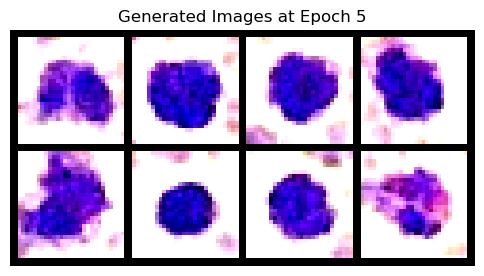

Sampling: 1000it [00:37, 26.52it/s]
Sampling: 1000it [00:36, 27.23it/s]


Epoch 5 FID: 214.1575
New best FID: 214.1575


Epoch 6/100: 100%|██████████| 268/268 [00:29<00:00,  9.04it/s]


Epoch 6/100 | Loss: 0.053298


Epoch 7/100: 100%|██████████| 268/268 [00:29<00:00,  8.99it/s]


...

Epoch 9/100: 100%|██████████| 268/268 [00:30<00:00,  8.92it/s]


Epoch 9/100 | Loss: 0.051125


Epoch 10/100: 100%|██████████| 268/268 [00:30<00:00,  8.71it/s]


Epoch 10/100 | Loss: 0.049252


Sampling: 1000it [00:09, 107.02it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


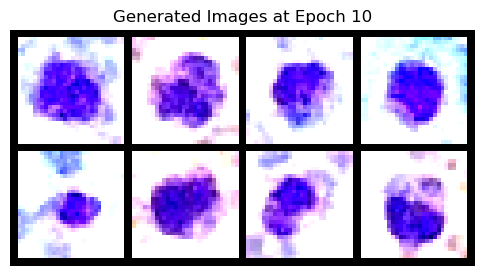

Sampling: 1000it [00:37, 26.45it/s]
Sampling: 1000it [00:37, 27.03it/s]


Epoch 10 FID: 203.2538
New best FID: 203.2538


Epoch 11/100: 100%|██████████| 268/268 [00:31<00:00,  8.38it/s]


Epoch 11/100 | Loss: 0.049985


Epoch 12/100: 100%|██████████| 268/268 [00:31<00:00,  8.47it/s]


...

Epoch 14/100: 100%|██████████| 268/268 [00:29<00:00,  9.00it/s]


Epoch 14/100 | Loss: 0.048523


Epoch 15/100: 100%|██████████| 268/268 [00:29<00:00,  9.00it/s]


Epoch 15/100 | Loss: 0.046780


Sampling: 1000it [00:09, 109.13it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


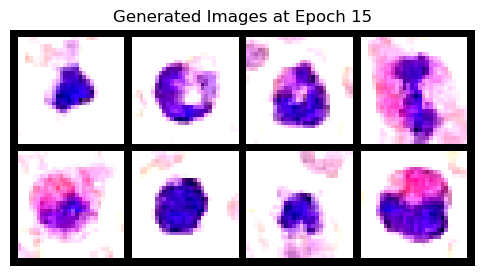

Sampling: 1000it [00:37, 26.45it/s]
Sampling: 1000it [00:36, 27.20it/s]


Epoch 15 FID: 136.0385
New best FID: 136.0385


Epoch 16/100: 100%|██████████| 268/268 [00:29<00:00,  9.05it/s]


Epoch 16/100 | Loss: 0.047464


Epoch 17/100: 100%|██████████| 268/268 [00:29<00:00,  9.04it/s]


...

Epoch 19/100: 100%|██████████| 268/268 [00:29<00:00,  9.11it/s]


Epoch 19/100 | Loss: 0.045322


Epoch 20/100: 100%|██████████| 268/268 [00:29<00:00,  9.07it/s]


Epoch 20/100 | Loss: 0.046685


Sampling: 1000it [00:09, 106.16it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


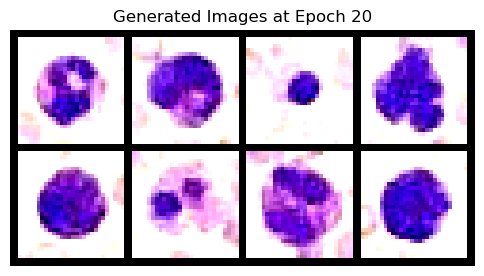

Sampling: 1000it [00:37, 26.35it/s]
Sampling: 1000it [00:36, 27.19it/s]


Epoch 20 FID: 126.0000
New best FID: 126.0000


Epoch 21/100: 100%|██████████| 268/268 [00:29<00:00,  8.99it/s]


Epoch 21/100 | Loss: 0.045321


Epoch 22/100: 100%|██████████| 268/268 [00:29<00:00,  9.09it/s]


...

Epoch 24/100: 100%|██████████| 268/268 [00:29<00:00,  9.08it/s]


Epoch 24/100 | Loss: 0.043823


Epoch 25/100: 100%|██████████| 268/268 [00:30<00:00,  8.83it/s]


Epoch 25/100 | Loss: 0.043809


Sampling: 1000it [00:09, 102.28it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


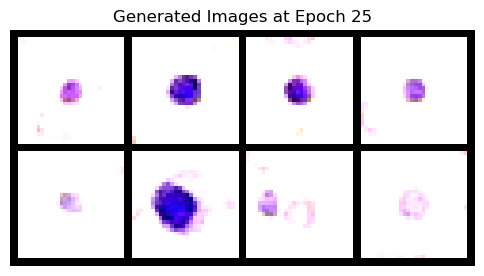

Sampling: 1000it [00:38, 26.31it/s]
Sampling: 1000it [00:36, 27.36it/s]


Epoch 25 FID: 187.1402
No improvement for 1 evaluations


Epoch 26/100: 100%|██████████| 268/268 [00:29<00:00,  9.08it/s]


Epoch 26/100 | Loss: 0.043152


Epoch 27/100: 100%|██████████| 268/268 [00:29<00:00,  9.11it/s]


...

Epoch 29/100: 100%|██████████| 268/268 [00:29<00:00,  9.17it/s]


Epoch 29/100 | Loss: 0.044153


Epoch 30/100: 100%|██████████| 268/268 [00:29<00:00,  9.09it/s]


Epoch 30/100 | Loss: 0.042342


Sampling: 1000it [00:09, 105.98it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


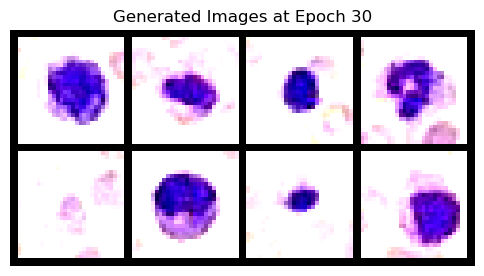

Sampling: 1000it [00:37, 26.42it/s]
Sampling: 1000it [00:36, 27.31it/s]


Epoch 30 FID: 95.6901
New best FID: 95.6901


Epoch 31/100: 100%|██████████| 268/268 [00:29<00:00,  9.09it/s]


Epoch 31/100 | Loss: 0.043842


Epoch 32/100: 100%|██████████| 268/268 [00:29<00:00,  9.08it/s]


...

Epoch 34/100: 100%|██████████| 268/268 [00:29<00:00,  9.13it/s]


Epoch 34/100 | Loss: 0.043500


Epoch 35/100: 100%|██████████| 268/268 [00:29<00:00,  9.19it/s]


Epoch 35/100 | Loss: 0.043673


Sampling: 1000it [00:09, 106.66it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


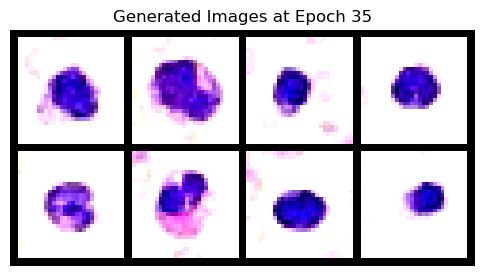

Sampling: 1000it [00:37, 26.42it/s]
Sampling: 1000it [00:36, 27.26it/s]


Epoch 35 FID: 102.8332
No improvement for 1 evaluations


Epoch 36/100: 100%|██████████| 268/268 [00:29<00:00,  9.15it/s]


Epoch 36/100 | Loss: 0.042921


Epoch 37/100: 100%|██████████| 268/268 [00:29<00:00,  9.01it/s]


...

Epoch 39/100: 100%|██████████| 268/268 [00:29<00:00,  9.09it/s]


Epoch 39/100 | Loss: 0.041860


Epoch 40/100: 100%|██████████| 268/268 [00:29<00:00,  9.06it/s]


Epoch 40/100 | Loss: 0.041003


Sampling: 1000it [00:09, 106.37it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


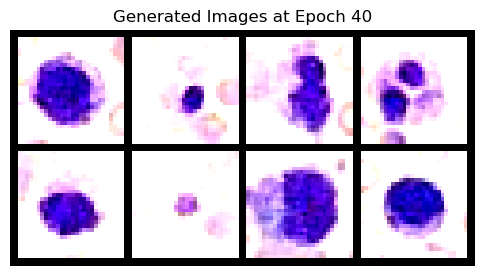

Sampling: 1000it [00:37, 26.60it/s]
Sampling: 1000it [00:36, 27.34it/s]


Epoch 40 FID: 84.5811
New best FID: 84.5811


Epoch 41/100: 100%|██████████| 268/268 [00:29<00:00,  9.21it/s]


Epoch 41/100 | Loss: 0.042404


Epoch 42/100: 100%|██████████| 268/268 [00:29<00:00,  9.05it/s]


...

Epoch 44/100: 100%|██████████| 268/268 [00:29<00:00,  9.11it/s]


Epoch 44/100 | Loss: 0.041670


Epoch 45/100: 100%|██████████| 268/268 [00:29<00:00,  9.02it/s]


Epoch 45/100 | Loss: 0.041682


Sampling: 1000it [00:09, 108.46it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


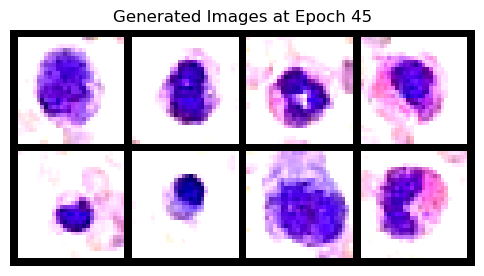

Sampling: 1000it [00:37, 26.57it/s]
Sampling: 1000it [00:36, 27.46it/s]


Epoch 45 FID: 80.5921
New best FID: 80.5921


Epoch 46/100: 100%|██████████| 268/268 [00:29<00:00,  9.17it/s]


Epoch 46/100 | Loss: 0.042386


Epoch 47/100: 100%|██████████| 268/268 [00:29<00:00,  8.99it/s]


...

Epoch 49/100: 100%|██████████| 268/268 [00:29<00:00,  9.03it/s]


Epoch 49/100 | Loss: 0.041823


Epoch 50/100: 100%|██████████| 268/268 [00:29<00:00,  9.10it/s]


Epoch 50/100 | Loss: 0.041658


Sampling: 1000it [00:09, 108.16it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


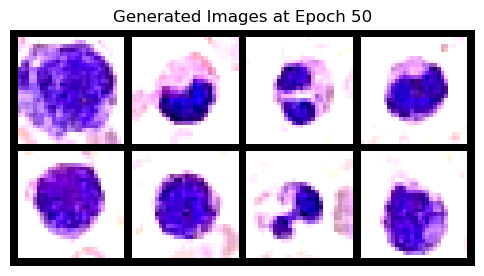

Sampling: 1000it [00:37, 26.48it/s]
Sampling: 1000it [00:36, 27.32it/s]


Epoch 50 FID: 78.2159
New best FID: 78.2159


Epoch 51/100: 100%|██████████| 268/268 [00:29<00:00,  9.19it/s]


Epoch 51/100 | Loss: 0.040734


Epoch 52/100: 100%|██████████| 268/268 [00:29<00:00,  9.07it/s]


...

Epoch 54/100: 100%|██████████| 268/268 [00:29<00:00,  9.08it/s]


Epoch 54/100 | Loss: 0.039672


Epoch 55/100: 100%|██████████| 268/268 [00:29<00:00,  8.99it/s]


Epoch 55/100 | Loss: 0.039647


Sampling: 1000it [00:09, 109.07it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


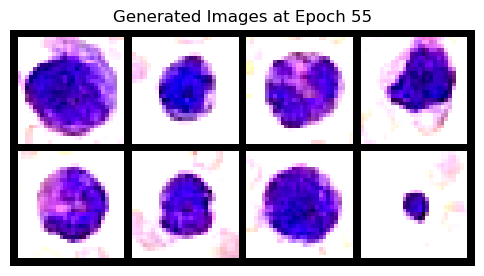

Sampling: 1000it [00:37, 26.59it/s]
Sampling: 1000it [00:36, 27.32it/s]


Epoch 55 FID: 64.2082
New best FID: 64.2082


Epoch 56/100: 100%|██████████| 268/268 [00:29<00:00,  9.17it/s]


Epoch 56/100 | Loss: 0.040184


Epoch 57/100: 100%|██████████| 268/268 [00:29<00:00,  9.00it/s]


...

Epoch 59/100: 100%|██████████| 268/268 [00:29<00:00,  9.02it/s]


Epoch 59/100 | Loss: 0.040167


Epoch 60/100: 100%|██████████| 268/268 [00:29<00:00,  9.01it/s]


Epoch 60/100 | Loss: 0.040919


Sampling: 1000it [00:09, 108.27it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


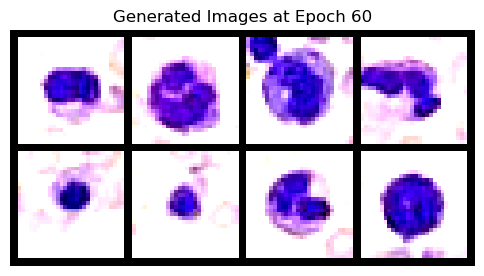

Sampling: 1000it [00:37, 26.55it/s]
Sampling: 1000it [00:36, 27.32it/s]


Epoch 60 FID: 74.4135
No improvement for 1 evaluations


Epoch 61/100: 100%|██████████| 268/268 [00:29<00:00,  9.12it/s]


Epoch 61/100 | Loss: 0.040642


Epoch 62/100: 100%|██████████| 268/268 [00:29<00:00,  8.94it/s]


...

Epoch 64/100: 100%|██████████| 268/268 [00:29<00:00,  9.02it/s]


Epoch 64/100 | Loss: 0.040136


Epoch 65/100: 100%|██████████| 268/268 [00:29<00:00,  9.05it/s]


Epoch 65/100 | Loss: 0.040502


Sampling: 1000it [00:09, 109.67it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


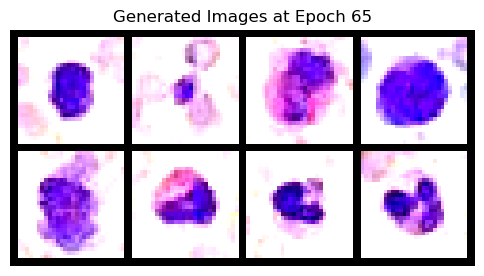

Sampling: 1000it [00:37, 26.55it/s]
Sampling: 1000it [00:36, 27.37it/s]


Epoch 65 FID: 78.1917
No improvement for 2 evaluations


Epoch 66/100: 100%|██████████| 268/268 [00:29<00:00,  9.16it/s]


Epoch 66/100 | Loss: 0.039952


Epoch 67/100: 100%|██████████| 268/268 [00:29<00:00,  9.07it/s]


...

Epoch 69/100: 100%|██████████| 268/268 [00:29<00:00,  9.00it/s]


Epoch 69/100 | Loss: 0.039914


Epoch 70/100: 100%|██████████| 268/268 [00:29<00:00,  9.13it/s]


Epoch 70/100 | Loss: 0.039021


Sampling: 1000it [00:09, 109.82it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


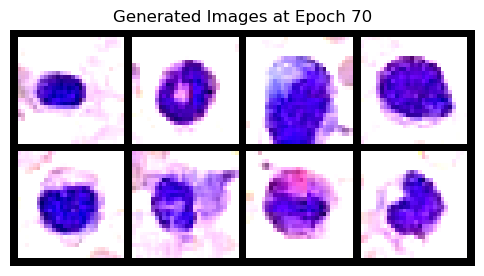

Sampling: 1000it [00:37, 26.48it/s]
Sampling: 1000it [00:36, 27.37it/s]


Epoch 70 FID: 87.0721
No improvement for 3 evaluations


Epoch 71/100: 100%|██████████| 268/268 [00:29<00:00,  9.14it/s]


Epoch 71/100 | Loss: 0.039718


Epoch 72/100: 100%|██████████| 268/268 [00:29<00:00,  9.00it/s]


...

Epoch 74/100: 100%|██████████| 268/268 [00:29<00:00,  9.02it/s]


Epoch 74/100 | Loss: 0.039746


Epoch 75/100: 100%|██████████| 268/268 [00:29<00:00,  9.01it/s]


Epoch 75/100 | Loss: 0.039823


Sampling: 1000it [00:09, 105.36it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


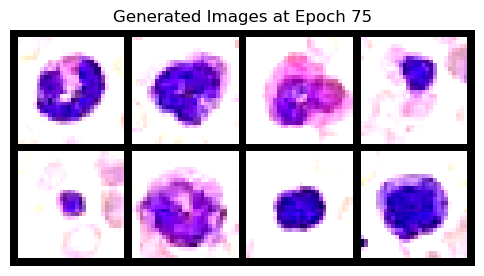

Sampling: 1000it [00:37, 26.41it/s]
Sampling: 1000it [00:36, 27.35it/s]


Epoch 75 FID: 62.6316
New best FID: 62.6316


Epoch 76/100: 100%|██████████| 268/268 [00:29<00:00,  9.13it/s]


Epoch 76/100 | Loss: 0.039568


Epoch 77/100: 100%|██████████| 268/268 [00:29<00:00,  8.99it/s]


...

Epoch 79/100: 100%|██████████| 268/268 [00:29<00:00,  8.98it/s]


Epoch 79/100 | Loss: 0.039518


Epoch 80/100: 100%|██████████| 268/268 [00:29<00:00,  9.07it/s]


Epoch 80/100 | Loss: 0.039384


Sampling: 1000it [00:09, 108.47it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


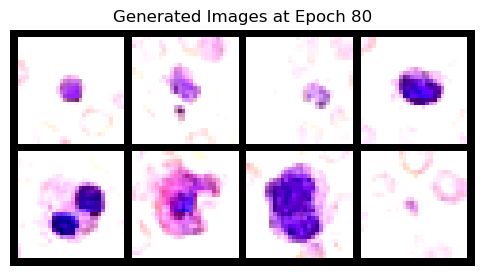

Sampling: 1000it [00:37, 26.58it/s]
Sampling: 1000it [00:36, 27.33it/s]


Epoch 80 FID: 68.9226
No improvement for 1 evaluations


Epoch 81/100: 100%|██████████| 268/268 [00:29<00:00,  9.08it/s]


Epoch 81/100 | Loss: 0.038876


Epoch 82/100: 100%|██████████| 268/268 [00:29<00:00,  9.08it/s]


...

Epoch 84/100: 100%|██████████| 268/268 [00:29<00:00,  9.02it/s]


Epoch 84/100 | Loss: 0.038852


Epoch 85/100: 100%|██████████| 268/268 [00:29<00:00,  8.99it/s]


Epoch 85/100 | Loss: 0.038580


Sampling: 1000it [00:09, 107.43it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


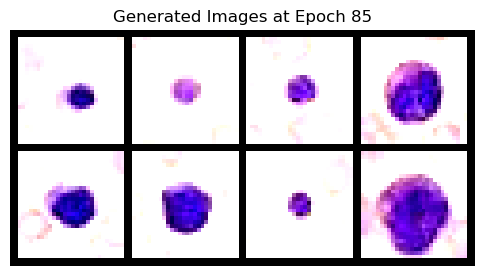

Sampling: 1000it [00:37, 26.44it/s]
Sampling: 1000it [00:36, 27.13it/s]


Epoch 85 FID: 59.8339
New best FID: 59.8339


Epoch 86/100: 100%|██████████| 268/268 [00:29<00:00,  9.07it/s]


Epoch 86/100 | Loss: 0.038915


Epoch 87/100: 100%|██████████| 268/268 [00:29<00:00,  9.07it/s]


...

Epoch 89/100: 100%|██████████| 268/268 [00:29<00:00,  9.14it/s]


Epoch 89/100 | Loss: 0.038669


Epoch 90/100: 100%|██████████| 268/268 [00:29<00:00,  9.11it/s]


Epoch 90/100 | Loss: 0.038458


Sampling: 1000it [00:09, 103.82it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


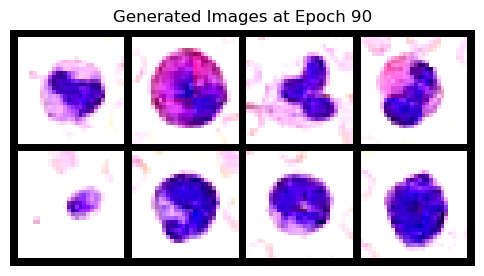

Sampling: 1000it [00:37, 26.45it/s]
Sampling: 1000it [00:36, 27.27it/s]


Epoch 90 FID: 69.7402
No improvement for 1 evaluations


Epoch 91/100: 100%|██████████| 268/268 [00:29<00:00,  9.09it/s]


Epoch 91/100 | Loss: 0.038841


Epoch 92/100: 100%|██████████| 268/268 [00:29<00:00,  9.14it/s]


...

Epoch 94/100: 100%|██████████| 268/268 [00:29<00:00,  9.07it/s]


Epoch 94/100 | Loss: 0.037259


Epoch 95/100: 100%|██████████| 268/268 [00:29<00:00,  9.09it/s]


Epoch 95/100 | Loss: 0.038433


Sampling: 1000it [00:09, 106.86it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


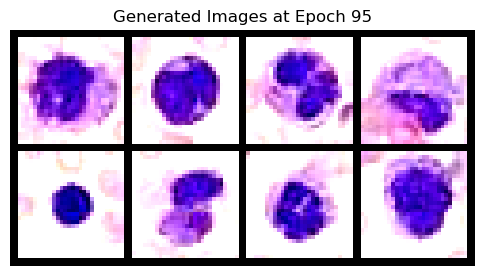

Sampling: 1000it [00:37, 26.41it/s]
Sampling: 1000it [00:36, 27.34it/s]


Epoch 95 FID: 63.3777
No improvement for 2 evaluations


Epoch 96/100: 100%|██████████| 268/268 [00:29<00:00,  9.09it/s]


Epoch 96/100 | Loss: 0.038606


Epoch 97/100: 100%|██████████| 268/268 [00:29<00:00,  9.14it/s]


...

Epoch 99/100: 100%|██████████| 268/268 [00:29<00:00,  9.19it/s]


Epoch 99/100 | Loss: 0.038898


Epoch 100/100: 100%|██████████| 268/268 [00:29<00:00,  9.07it/s]


Epoch 100/100 | Loss: 0.038361


Sampling: 1000it [00:09, 105.72it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


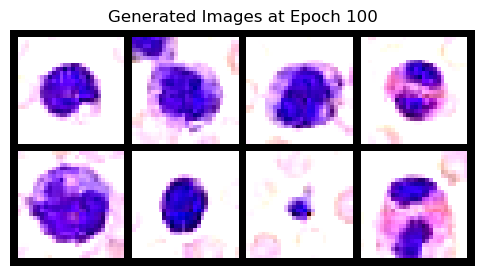

Sampling: 1000it [00:37, 26.49it/s]
Sampling: 1000it [00:36, 27.28it/s]


Epoch 100 FID: 77.2337
No improvement for 3 evaluations


Sampling: 1000it [00:37, 26.35it/s]
Sampling: 1000it [00:38, 26.31it/s]
Sampling: 1000it [00:37, 26.35it/s]
Sampling: 1000it [00:37, 26.45it/s]
Sampling: 1000it [00:37, 26.55it/s]
Sampling: 1000it [00:37, 26.52it/s]
Sampling: 1000it [00:37, 26.45it/s]
Sampling: 1000it [00:32, 31.16it/s]


FID Score: 45.1645

Hyperparameter combination 4/6
Configuration: {'batch_size': 128, 'epochs': 100, 'learning_rate': 0.0002, 'model_channels': 128, 'time_emb_dim': 256}


Epoch 1/100: 100%|██████████| 268/268 [00:56<00:00,  4.72it/s]


...

Epoch 4/100: 100%|██████████| 268/268 [00:57<00:00,  4.69it/s]


Epoch 4/100 | Loss: 0.053902


Epoch 5/100: 100%|██████████| 268/268 [00:57<00:00,  4.69it/s]


Epoch 5/100 | Loss: 0.052175


Sampling: 1000it [00:14, 70.53it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


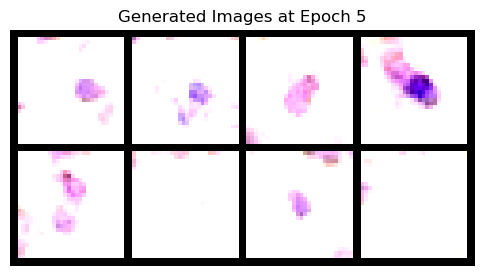

Sampling: 1000it [01:43,  9.67it/s]
Sampling: 1000it [01:43,  9.67it/s]


Epoch 5 FID: 223.8037
New best FID: 223.8037


Epoch 6/100: 100%|██████████| 268/268 [00:56<00:00,  4.71it/s]


Epoch 6/100 | Loss: 0.049453


Epoch 7/100: 100%|██████████| 268/268 [00:56<00:00,  4.72it/s]


...

Epoch 9/100: 100%|██████████| 268/268 [00:56<00:00,  4.72it/s]


Epoch 9/100 | Loss: 0.047436


Epoch 10/100: 100%|██████████| 268/268 [00:56<00:00,  4.74it/s]


Epoch 10/100 | Loss: 0.045742


Sampling: 1000it [00:13, 71.98it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


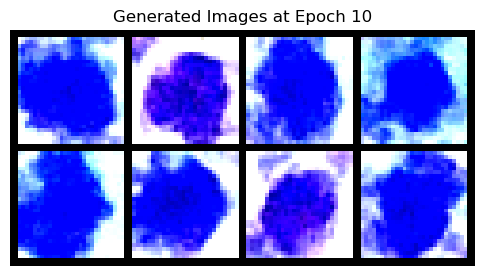

Sampling: 1000it [01:43,  9.69it/s]
Sampling: 1000it [01:43,  9.67it/s]


Epoch 10 FID: 277.9874
No improvement for 1 evaluations


Epoch 11/100: 100%|██████████| 268/268 [00:56<00:00,  4.71it/s]


Epoch 11/100 | Loss: 0.046411


Epoch 12/100: 100%|██████████| 268/268 [00:56<00:00,  4.71it/s]


...

Epoch 14/100: 100%|██████████| 268/268 [00:57<00:00,  4.70it/s]


Epoch 14/100 | Loss: 0.045078


Epoch 15/100: 100%|██████████| 268/268 [00:57<00:00,  4.69it/s]


Epoch 15/100 | Loss: 0.043583


Sampling: 1000it [00:13, 72.54it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


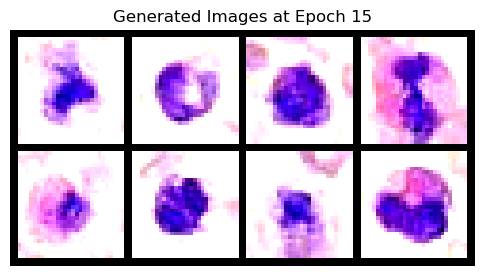

Sampling: 1000it [01:42,  9.72it/s]
Sampling: 1000it [01:42,  9.71it/s]


Epoch 15 FID: 152.9355
New best FID: 152.9355


Epoch 16/100: 100%|██████████| 268/268 [00:56<00:00,  4.73it/s]


Epoch 16/100 | Loss: 0.043959


Epoch 17/100: 100%|██████████| 268/268 [00:56<00:00,  4.72it/s]


...

Epoch 19/100: 100%|██████████| 268/268 [00:57<00:00,  4.69it/s]


Epoch 19/100 | Loss: 0.041871


Epoch 20/100: 100%|██████████| 268/268 [00:57<00:00,  4.69it/s]


Epoch 20/100 | Loss: 0.043181


Sampling: 1000it [00:13, 72.74it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


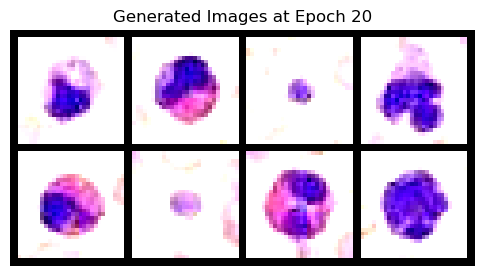

Sampling: 1000it [01:43,  9.69it/s]
Sampling: 1000it [01:43,  9.70it/s]


Epoch 20 FID: 134.3809
New best FID: 134.3809


Epoch 21/100: 100%|██████████| 268/268 [00:56<00:00,  4.72it/s]


Epoch 21/100 | Loss: 0.041569


Epoch 22/100: 100%|██████████| 268/268 [00:57<00:00,  4.70it/s]


...

Epoch 24/100: 100%|██████████| 268/268 [00:57<00:00,  4.69it/s]


Epoch 24/100 | Loss: 0.040223


Epoch 25/100: 100%|██████████| 268/268 [00:57<00:00,  4.70it/s]


Epoch 25/100 | Loss: 0.040346


Sampling: 1000it [00:13, 72.43it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


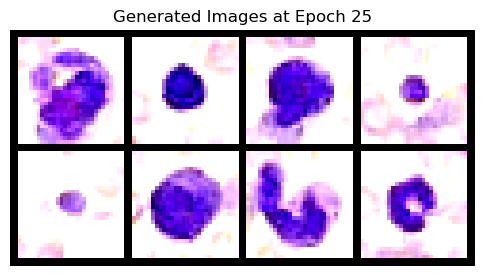

Sampling: 1000it [01:43,  9.70it/s]
Sampling: 1000it [01:43,  9.68it/s]


Epoch 25 FID: 94.1993
New best FID: 94.1993


Epoch 26/100: 100%|██████████| 268/268 [00:56<00:00,  4.73it/s]


Epoch 26/100 | Loss: 0.039813


Epoch 27/100: 100%|██████████| 268/268 [00:56<00:00,  4.73it/s]


...

Epoch 29/100: 100%|██████████| 268/268 [00:57<00:00,  4.69it/s]


Epoch 29/100 | Loss: 0.040346


Epoch 30/100: 100%|██████████| 268/268 [00:57<00:00,  4.70it/s]


Epoch 30/100 | Loss: 0.038938


Sampling: 1000it [00:13, 72.48it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


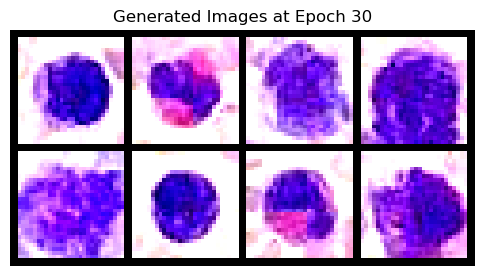

Sampling: 1000it [01:42,  9.71it/s]
Sampling: 1000it [01:43,  9.70it/s]


Epoch 30 FID: 218.9344
No improvement for 1 evaluations


Epoch 31/100: 100%|██████████| 268/268 [00:56<00:00,  4.75it/s]


Epoch 31/100 | Loss: 0.040340


Epoch 32/100: 100%|██████████| 268/268 [00:57<00:00,  4.68it/s]


...

Epoch 34/100: 100%|██████████| 268/268 [00:57<00:00,  4.69it/s]


Epoch 34/100 | Loss: 0.039766


Epoch 35/100: 100%|██████████| 268/268 [00:57<00:00,  4.66it/s]


Epoch 35/100 | Loss: 0.040033


Sampling: 1000it [00:13, 72.70it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


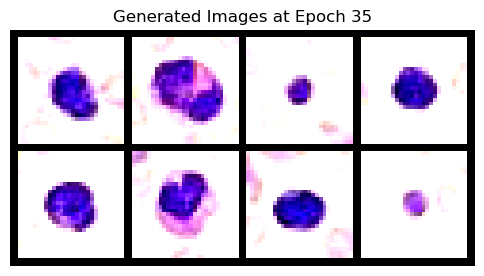

Sampling: 1000it [01:42,  9.72it/s]
Sampling: 1000it [01:43,  9.67it/s]


Epoch 35 FID: 74.9914
New best FID: 74.9914


Epoch 36/100: 100%|██████████| 268/268 [00:56<00:00,  4.74it/s]


Epoch 36/100 | Loss: 0.039653


Epoch 37/100: 100%|██████████| 268/268 [00:56<00:00,  4.70it/s]


...

Epoch 39/100: 100%|██████████| 268/268 [00:57<00:00,  4.69it/s]


Epoch 39/100 | Loss: 0.038705


Epoch 40/100: 100%|██████████| 268/268 [00:56<00:00,  4.70it/s]


Epoch 40/100 | Loss: 0.037881


Sampling: 1000it [00:13, 73.00it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


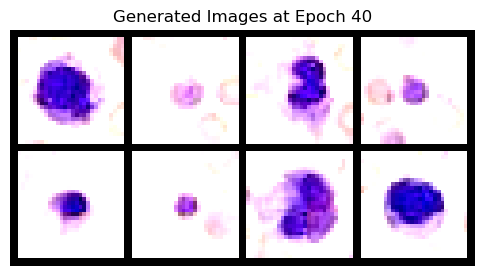

Sampling: 1000it [01:43,  9.70it/s]
Sampling: 1000it [01:43,  9.70it/s]


Epoch 40 FID: 79.0307
No improvement for 1 evaluations


Epoch 41/100: 100%|██████████| 268/268 [00:56<00:00,  4.74it/s]


Epoch 41/100 | Loss: 0.038949


Epoch 42/100: 100%|██████████| 268/268 [00:56<00:00,  4.70it/s]


...

Epoch 44/100: 100%|██████████| 268/268 [00:57<00:00,  4.70it/s]


Epoch 44/100 | Loss: 0.038348


Epoch 45/100: 100%|██████████| 268/268 [00:57<00:00,  4.70it/s]


Epoch 45/100 | Loss: 0.038129


Sampling: 1000it [00:13, 72.30it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


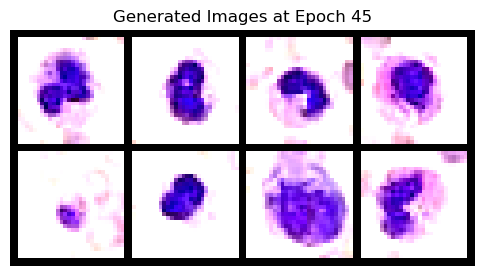

Sampling: 1000it [01:43,  9.70it/s]
Sampling: 1000it [01:43,  9.70it/s]


Epoch 45 FID: 82.7441
No improvement for 2 evaluations


Epoch 46/100: 100%|██████████| 268/268 [00:56<00:00,  4.75it/s]


Epoch 46/100 | Loss: 0.039474


Epoch 47/100: 100%|██████████| 268/268 [00:56<00:00,  4.72it/s]


...

Epoch 49/100: 100%|██████████| 268/268 [00:56<00:00,  4.72it/s]


Epoch 49/100 | Loss: 0.038663


Epoch 50/100: 100%|██████████| 268/268 [00:56<00:00,  4.70it/s]


Epoch 50/100 | Loss: 0.038839


Sampling: 1000it [00:13, 73.18it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


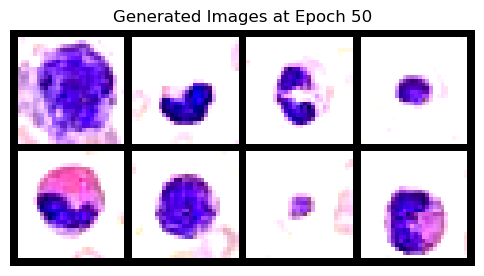

Sampling: 1000it [01:43,  9.69it/s]
Sampling: 1000it [01:43,  9.71it/s]


Epoch 50 FID: 64.9463
New best FID: 64.9463


Epoch 51/100: 100%|██████████| 268/268 [00:56<00:00,  4.73it/s]


Epoch 51/100 | Loss: 0.037596


Epoch 52/100: 100%|██████████| 268/268 [00:57<00:00,  4.70it/s]


...

Epoch 54/100: 100%|██████████| 268/268 [00:57<00:00,  4.69it/s]


Epoch 54/100 | Loss: 0.036535


Epoch 55/100: 100%|██████████| 268/268 [00:57<00:00,  4.70it/s]


Epoch 55/100 | Loss: 0.036334


Sampling: 1000it [00:13, 72.04it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


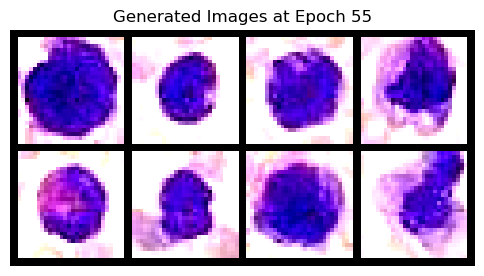

Sampling: 1000it [01:43,  9.70it/s]
Sampling: 1000it [01:43,  9.69it/s]


Epoch 55 FID: 119.7469
No improvement for 1 evaluations


Epoch 56/100: 100%|██████████| 268/268 [00:56<00:00,  4.74it/s]


Epoch 56/100 | Loss: 0.036985


Epoch 57/100: 100%|██████████| 268/268 [00:57<00:00,  4.68it/s]


...

Epoch 59/100: 100%|██████████| 268/268 [00:57<00:00,  4.68it/s]


Epoch 59/100 | Loss: 0.037004


Epoch 60/100: 100%|██████████| 268/268 [00:57<00:00,  4.69it/s]


Epoch 60/100 | Loss: 0.037742


Sampling: 1000it [00:13, 72.07it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


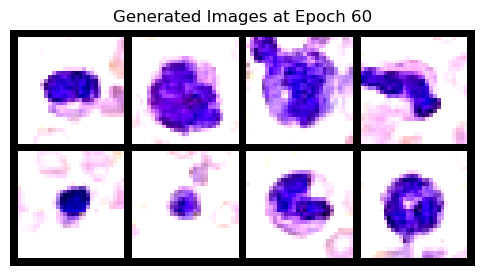

Sampling: 1000it [01:43,  9.70it/s]
Sampling: 1000it [01:42,  9.72it/s]


Epoch 60 FID: 86.3562
No improvement for 2 evaluations


Epoch 61/100: 100%|██████████| 268/268 [00:56<00:00,  4.74it/s]


Epoch 61/100 | Loss: 0.037397


Epoch 62/100: 100%|██████████| 268/268 [00:57<00:00,  4.69it/s]


...

Epoch 64/100: 100%|██████████| 268/268 [00:57<00:00,  4.69it/s]


Epoch 64/100 | Loss: 0.037057


Epoch 65/100: 100%|██████████| 268/268 [00:57<00:00,  4.69it/s]


Epoch 65/100 | Loss: 0.037273


Sampling: 1000it [00:13, 72.03it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


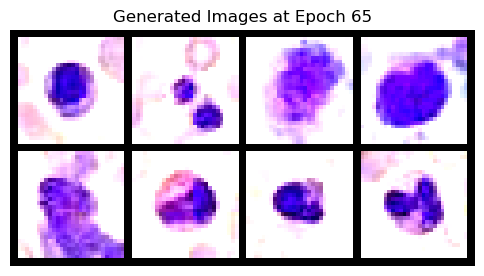

Sampling: 1000it [01:42,  9.71it/s]
Sampling: 1000it [01:43,  9.70it/s]


Epoch 65 FID: 73.3187
No improvement for 3 evaluations


Epoch 66/100: 100%|██████████| 268/268 [00:56<00:00,  4.76it/s]


Epoch 66/100 | Loss: 0.036883


Epoch 67/100: 100%|██████████| 268/268 [00:57<00:00,  4.69it/s]


...

Epoch 69/100: 100%|██████████| 268/268 [00:57<00:00,  4.70it/s]


Epoch 69/100 | Loss: 0.036833


Epoch 70/100: 100%|██████████| 268/268 [00:57<00:00,  4.69it/s]


Epoch 70/100 | Loss: 0.036005


Sampling: 1000it [00:13, 72.43it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


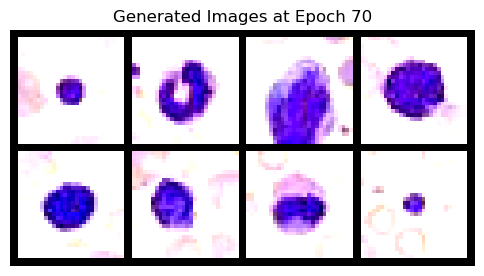

Sampling: 1000it [01:42,  9.71it/s]
Sampling: 1000it [01:43,  9.68it/s]


Epoch 70 FID: 56.4587
New best FID: 56.4587


Epoch 71/100: 100%|██████████| 268/268 [00:56<00:00,  4.75it/s]


Epoch 71/100 | Loss: 0.036610


Epoch 72/100: 100%|██████████| 268/268 [00:57<00:00,  4.70it/s]


...

Epoch 74/100: 100%|██████████| 268/268 [00:57<00:00,  4.69it/s]


Epoch 74/100 | Loss: 0.036760


Epoch 75/100: 100%|██████████| 268/268 [00:57<00:00,  4.69it/s]


Epoch 75/100 | Loss: 0.036832


Sampling: 1000it [00:13, 72.60it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


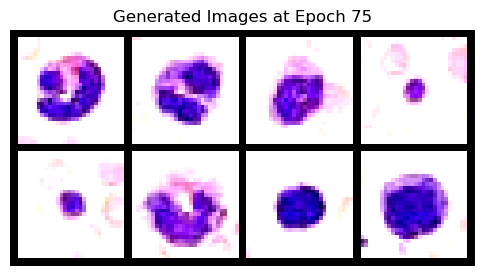

Sampling: 1000it [01:42,  9.72it/s]
Sampling: 1000it [01:43,  9.71it/s]


Epoch 75 FID: 62.6061
No improvement for 1 evaluations


Epoch 76/100: 100%|██████████| 268/268 [00:56<00:00,  4.74it/s]


Epoch 76/100 | Loss: 0.036636


Epoch 77/100: 100%|██████████| 268/268 [00:57<00:00,  4.69it/s]


...

Epoch 79/100: 100%|██████████| 268/268 [00:57<00:00,  4.69it/s]


Epoch 79/100 | Loss: 0.036652


Epoch 80/100: 100%|██████████| 268/268 [00:57<00:00,  4.69it/s]


Epoch 80/100 | Loss: 0.036659


Sampling: 1000it [00:13, 73.36it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


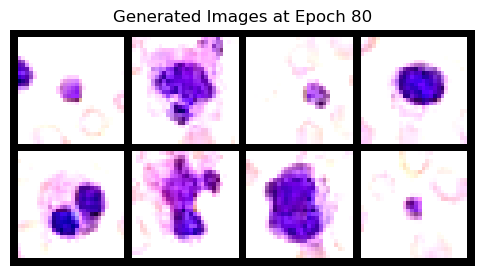

Sampling: 1000it [01:42,  9.73it/s]
Sampling: 1000it [01:42,  9.74it/s]


Epoch 80 FID: 66.2920
No improvement for 2 evaluations


Epoch 81/100: 100%|██████████| 268/268 [00:56<00:00,  4.74it/s]


Epoch 81/100 | Loss: 0.035787


Epoch 82/100: 100%|██████████| 268/268 [00:57<00:00,  4.70it/s]


...

Epoch 84/100: 100%|██████████| 268/268 [00:57<00:00,  4.69it/s]


Epoch 84/100 | Loss: 0.035840


Epoch 85/100: 100%|██████████| 268/268 [00:56<00:00,  4.71it/s]


Epoch 85/100 | Loss: 0.035721


Sampling: 1000it [00:13, 73.20it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


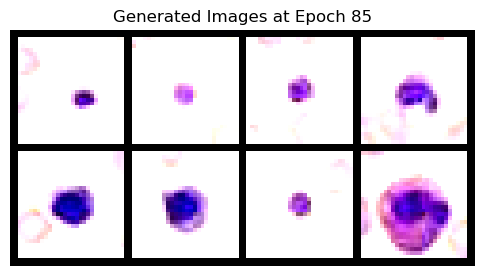

Sampling: 1000it [01:42,  9.74it/s]
Sampling: 1000it [01:42,  9.76it/s]


Epoch 85 FID: 80.4896
No improvement for 3 evaluations


Epoch 86/100: 100%|██████████| 268/268 [00:56<00:00,  4.75it/s]


Epoch 86/100 | Loss: 0.036058


Epoch 87/100: 100%|██████████| 268/268 [00:56<00:00,  4.70it/s]


...

Epoch 89/100: 100%|██████████| 268/268 [00:57<00:00,  4.70it/s]


Epoch 89/100 | Loss: 0.035839


Epoch 90/100: 100%|██████████| 268/268 [00:56<00:00,  4.71it/s]


Epoch 90/100 | Loss: 0.035653


Sampling: 1000it [00:13, 72.99it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


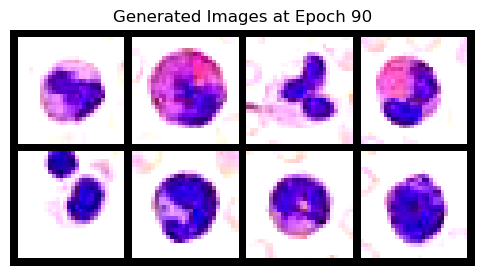

Sampling: 1000it [01:42,  9.72it/s]
Sampling: 1000it [01:42,  9.73it/s]


Epoch 90 FID: 54.7682
New best FID: 54.7682


Epoch 91/100: 100%|██████████| 268/268 [00:56<00:00,  4.74it/s]


Epoch 91/100 | Loss: 0.035976


Epoch 92/100: 100%|██████████| 268/268 [00:57<00:00,  4.70it/s]


...

Epoch 94/100: 100%|██████████| 268/268 [00:56<00:00,  4.70it/s]


Epoch 94/100 | Loss: 0.034657


Epoch 95/100: 100%|██████████| 268/268 [00:56<00:00,  4.71it/s]


Epoch 95/100 | Loss: 0.035534


Sampling: 1000it [00:13, 72.55it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


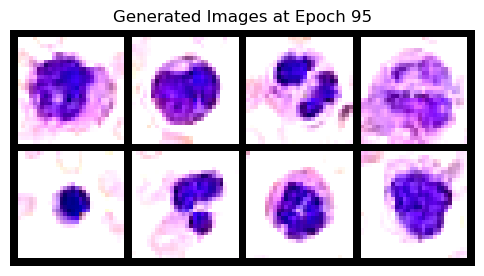

Sampling: 1000it [01:43,  9.68it/s]
Sampling: 1000it [01:42,  9.72it/s]


Epoch 95 FID: 49.9759
New best FID: 49.9759


Epoch 96/100: 100%|██████████| 268/268 [00:59<00:00,  4.52it/s]


Epoch 96/100 | Loss: 0.035825


Epoch 97/100: 100%|██████████| 268/268 [00:57<00:00,  4.70it/s]


...

Epoch 99/100: 100%|██████████| 268/268 [00:56<00:00,  4.71it/s]


Epoch 99/100 | Loss: 0.035769


Epoch 100/100: 100%|██████████| 268/268 [00:57<00:00,  4.70it/s]


Epoch 100/100 | Loss: 0.035809


Sampling: 1000it [00:13, 73.70it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


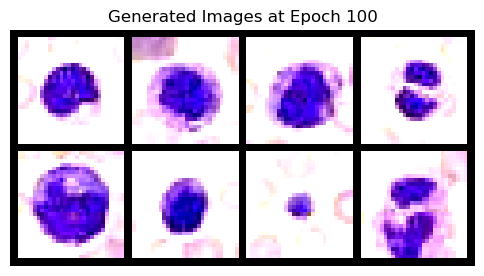

Sampling: 1000it [01:42,  9.74it/s]
Sampling: 1000it [01:42,  9.74it/s]


Epoch 100 FID: 64.7996
No improvement for 1 evaluations


Sampling: 1000it [01:42,  9.72it/s]
Sampling: 1000it [01:42,  9.72it/s]
Sampling: 1000it [01:42,  9.73it/s]
Sampling: 1000it [01:43,  9.71it/s]
Sampling: 1000it [01:42,  9.72it/s]
Sampling: 1000it [01:42,  9.72it/s]
Sampling: 1000it [01:42,  9.72it/s]
Sampling: 1000it [01:26, 11.58it/s]


FID Score: 38.4036

Hyperparameter combination 5/6
Configuration: {'batch_size': 128, 'epochs': 100, 'learning_rate': 0.0005, 'model_channels': 64, 'time_emb_dim': 256}


Epoch 1/100: 100%|██████████| 268/268 [00:29<00:00,  9.17it/s]


...

Epoch 4/100: 100%|██████████| 268/268 [00:29<00:00,  9.02it/s]


Epoch 4/100 | Loss: 0.055408


Epoch 5/100: 100%|██████████| 268/268 [00:29<00:00,  9.03it/s]


Epoch 5/100 | Loss: 0.052867


Sampling: 1000it [00:09, 109.44it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


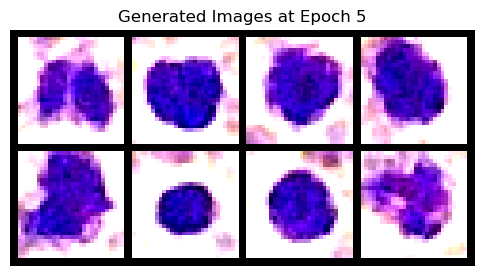

Sampling: 1000it [00:37, 26.68it/s]
Sampling: 1000it [00:36, 27.55it/s]


Epoch 5 FID: 228.2241
New best FID: 228.2241


Epoch 6/100: 100%|██████████| 268/268 [00:29<00:00,  9.20it/s]


Epoch 6/100 | Loss: 0.050232


Epoch 7/100: 100%|██████████| 268/268 [00:29<00:00,  9.00it/s]


...

Epoch 9/100: 100%|██████████| 268/268 [00:29<00:00,  9.01it/s]


Epoch 9/100 | Loss: 0.048434


Epoch 10/100: 100%|██████████| 268/268 [00:29<00:00,  9.04it/s]


Epoch 10/100 | Loss: 0.046673


Sampling: 1000it [00:08, 111.66it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


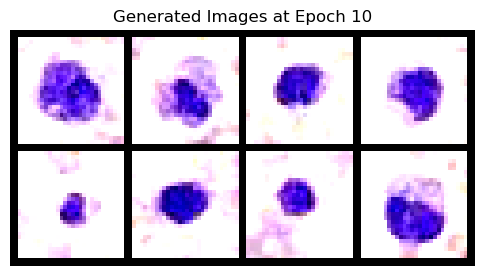

Sampling: 1000it [00:37, 26.71it/s]
Sampling: 1000it [00:36, 27.50it/s]


Epoch 10 FID: 168.2476
New best FID: 168.2476


Epoch 11/100: 100%|██████████| 268/268 [00:29<00:00,  9.17it/s]


Epoch 11/100 | Loss: 0.047444


Epoch 12/100: 100%|██████████| 268/268 [00:29<00:00,  9.01it/s]


...

Epoch 14/100: 100%|██████████| 268/268 [00:29<00:00,  9.04it/s]


Epoch 14/100 | Loss: 0.046223


Epoch 15/100: 100%|██████████| 268/268 [00:29<00:00,  9.10it/s]


Epoch 15/100 | Loss: 0.044510


Sampling: 1000it [00:09, 108.85it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


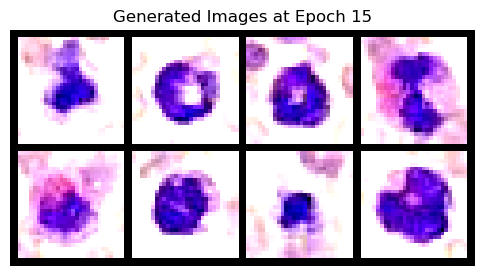

Sampling: 1000it [00:37, 26.62it/s]
Sampling: 1000it [00:36, 27.49it/s]


Epoch 15 FID: 137.6548
New best FID: 137.6548


Epoch 16/100: 100%|██████████| 268/268 [00:29<00:00,  9.21it/s]


Epoch 16/100 | Loss: 0.045423


Epoch 17/100: 100%|██████████| 268/268 [00:29<00:00,  9.04it/s]


...

Epoch 19/100: 100%|██████████| 268/268 [00:29<00:00,  9.04it/s]


Epoch 19/100 | Loss: 0.043225


Epoch 20/100: 100%|██████████| 268/268 [00:29<00:00,  9.09it/s]


Epoch 20/100 | Loss: 0.044683


Sampling: 1000it [00:09, 107.80it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


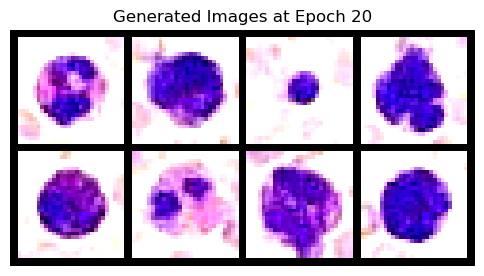

Sampling: 1000it [00:37, 26.75it/s]
Sampling: 1000it [00:36, 27.62it/s]


Epoch 20 FID: 110.3294
New best FID: 110.3294


Epoch 21/100: 100%|██████████| 268/268 [00:29<00:00,  9.19it/s]


Epoch 21/100 | Loss: 0.043442


Epoch 22/100: 100%|██████████| 268/268 [00:29<00:00,  8.99it/s]


...

Epoch 24/100: 100%|██████████| 268/268 [00:29<00:00,  9.02it/s]


Epoch 24/100 | Loss: 0.042151


Epoch 25/100: 100%|██████████| 268/268 [00:29<00:00,  8.98it/s]


Epoch 25/100 | Loss: 0.042041


Sampling: 1000it [00:09, 108.74it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


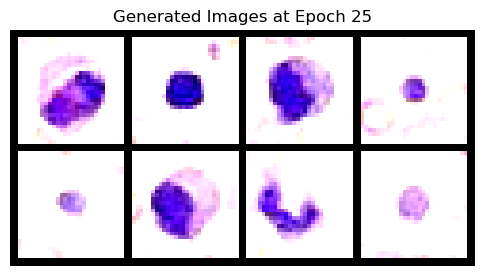

Sampling: 1000it [00:37, 26.76it/s]
Sampling: 1000it [00:36, 27.52it/s]


Epoch 25 FID: 123.9252
No improvement for 1 evaluations


Epoch 26/100: 100%|██████████| 268/268 [00:29<00:00,  9.23it/s]


Epoch 26/100 | Loss: 0.041470


Epoch 27/100: 100%|██████████| 268/268 [00:29<00:00,  9.12it/s]


...

Epoch 29/100: 100%|██████████| 268/268 [00:29<00:00,  9.13it/s]


Epoch 29/100 | Loss: 0.042396


Epoch 30/100: 100%|██████████| 268/268 [00:29<00:00,  9.02it/s]


Epoch 30/100 | Loss: 0.040611


Sampling: 1000it [00:09, 109.95it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


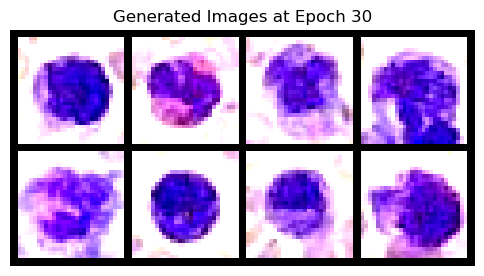

Sampling: 1000it [00:37, 26.76it/s]
Sampling: 1000it [00:36, 27.59it/s]


Epoch 30 FID: 164.3628
No improvement for 2 evaluations


Epoch 31/100: 100%|██████████| 268/268 [00:29<00:00,  9.19it/s]


Epoch 31/100 | Loss: 0.042118


Epoch 32/100: 100%|██████████| 268/268 [00:29<00:00,  9.06it/s]


...

Epoch 34/100: 100%|██████████| 268/268 [00:29<00:00,  9.02it/s]


Epoch 34/100 | Loss: 0.041489


Epoch 35/100: 100%|██████████| 268/268 [00:29<00:00,  9.07it/s]


Epoch 35/100 | Loss: 0.041861


Sampling: 1000it [00:09, 107.65it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


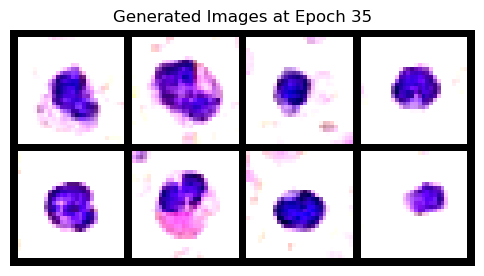

Sampling: 1000it [00:37, 26.67it/s]
Sampling: 1000it [00:36, 27.47it/s]


Epoch 35 FID: 90.5522
New best FID: 90.5522


Epoch 36/100: 100%|██████████| 268/268 [00:29<00:00,  9.21it/s]


Epoch 36/100 | Loss: 0.041081


Epoch 37/100: 100%|██████████| 268/268 [00:29<00:00,  8.98it/s]


...

Epoch 39/100: 100%|██████████| 268/268 [00:29<00:00,  9.03it/s]


Epoch 39/100 | Loss: 0.040019


Epoch 40/100: 100%|██████████| 268/268 [00:29<00:00,  9.02it/s]


Epoch 40/100 | Loss: 0.039188


Sampling: 1000it [00:09, 110.30it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


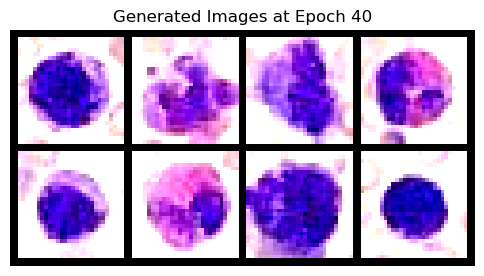

Sampling: 1000it [00:37, 26.79it/s]
Sampling: 1000it [00:36, 27.58it/s]


Epoch 40 FID: 163.4381
No improvement for 1 evaluations


Epoch 41/100: 100%|██████████| 268/268 [00:29<00:00,  9.16it/s]


Epoch 41/100 | Loss: 0.040657


Epoch 42/100: 100%|██████████| 268/268 [00:29<00:00,  8.96it/s]


...

Epoch 44/100: 100%|██████████| 268/268 [00:29<00:00,  9.12it/s]


Epoch 44/100 | Loss: 0.039767


Epoch 45/100: 100%|██████████| 268/268 [00:29<00:00,  9.03it/s]


Epoch 45/100 | Loss: 0.039924


Sampling: 1000it [00:09, 109.66it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


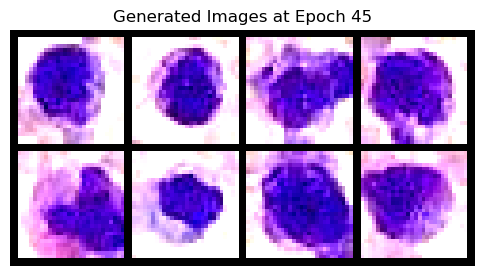

Sampling: 1000it [00:37, 26.80it/s]
Sampling: 1000it [00:36, 27.67it/s]


Epoch 45 FID: 184.6803
No improvement for 2 evaluations


Epoch 46/100: 100%|██████████| 268/268 [00:29<00:00,  9.17it/s]


Epoch 46/100 | Loss: 0.040591


Epoch 47/100: 100%|██████████| 268/268 [00:29<00:00,  9.01it/s]


...

Epoch 49/100: 100%|██████████| 268/268 [00:29<00:00,  9.03it/s]


Epoch 49/100 | Loss: 0.040019


Epoch 50/100: 100%|██████████| 268/268 [00:29<00:00,  9.10it/s]


Epoch 50/100 | Loss: 0.040232


Sampling: 1000it [00:09, 110.91it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


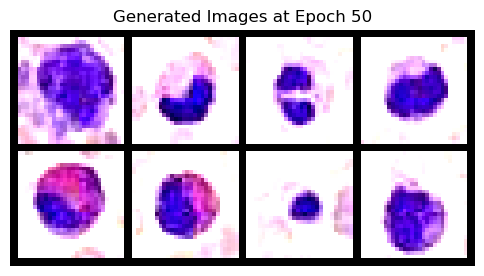

Sampling: 1000it [00:37, 26.82it/s]
Sampling: 1000it [00:36, 27.56it/s]


Epoch 50 FID: 60.8196
New best FID: 60.8196


Epoch 51/100: 100%|██████████| 268/268 [00:29<00:00,  9.16it/s]


Epoch 51/100 | Loss: 0.039065


Epoch 52/100: 100%|██████████| 268/268 [00:29<00:00,  9.09it/s]


...

Epoch 54/100: 100%|██████████| 268/268 [00:29<00:00,  9.04it/s]


Epoch 54/100 | Loss: 0.038072


Epoch 55/100: 100%|██████████| 268/268 [00:29<00:00,  9.03it/s]


Epoch 55/100 | Loss: 0.038020


Sampling: 1000it [00:09, 110.98it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


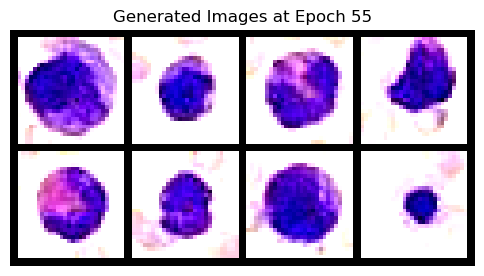

Sampling: 1000it [00:37, 26.76it/s]
Sampling: 1000it [00:36, 27.62it/s]


Epoch 55 FID: 64.8382
No improvement for 1 evaluations


Epoch 56/100: 100%|██████████| 268/268 [00:28<00:00,  9.24it/s]


Epoch 56/100 | Loss: 0.038501


Epoch 57/100: 100%|██████████| 268/268 [00:29<00:00,  9.08it/s]


...

Epoch 59/100: 100%|██████████| 268/268 [00:29<00:00,  9.03it/s]


Epoch 59/100 | Loss: 0.038671


Epoch 60/100: 100%|██████████| 268/268 [00:29<00:00,  9.01it/s]


Epoch 60/100 | Loss: 0.039302


Sampling: 1000it [00:09, 109.38it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


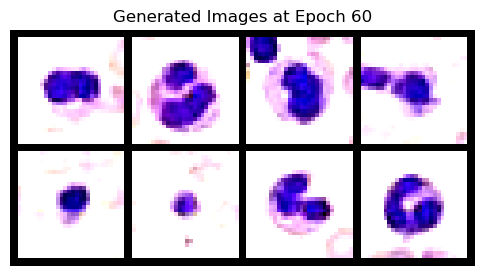

Sampling: 1000it [00:37, 26.76it/s]
Sampling: 1000it [00:36, 27.60it/s]


Epoch 60 FID: 63.0852
No improvement for 2 evaluations


Epoch 61/100: 100%|██████████| 268/268 [00:29<00:00,  9.14it/s]


Epoch 61/100 | Loss: 0.039109


Epoch 62/100: 100%|██████████| 268/268 [00:29<00:00,  9.05it/s]


...

Epoch 64/100: 100%|██████████| 268/268 [00:29<00:00,  9.03it/s]


Epoch 64/100 | Loss: 0.038609


Epoch 65/100: 100%|██████████| 268/268 [00:29<00:00,  9.13it/s]


Epoch 65/100 | Loss: 0.038973


Sampling: 1000it [00:09, 109.07it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


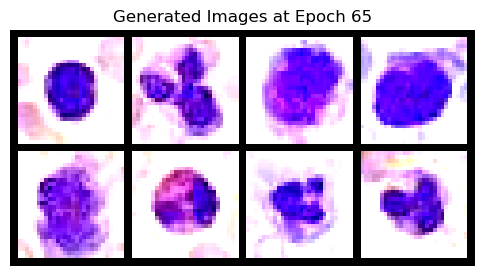

Sampling: 1000it [00:37, 26.69it/s]
Sampling: 1000it [00:36, 27.46it/s]


Epoch 65 FID: 86.5307
No improvement for 3 evaluations


Epoch 66/100: 100%|██████████| 268/268 [00:29<00:00,  9.16it/s]


Epoch 66/100 | Loss: 0.038530


Epoch 67/100: 100%|██████████| 268/268 [00:29<00:00,  9.01it/s]


...

Epoch 69/100: 100%|██████████| 268/268 [00:29<00:00,  9.08it/s]


Epoch 69/100 | Loss: 0.038589


Epoch 70/100: 100%|██████████| 268/268 [00:29<00:00,  9.03it/s]


Epoch 70/100 | Loss: 0.037590


Sampling: 1000it [00:08, 111.24it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


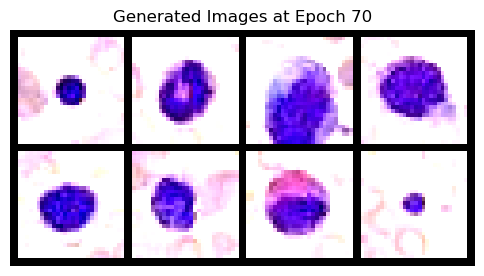

Sampling: 1000it [00:37, 26.83it/s]
Sampling: 1000it [00:36, 27.64it/s]


Epoch 70 FID: 74.8704
No improvement for 4 evaluations


Epoch 71/100: 100%|██████████| 268/268 [00:29<00:00,  9.19it/s]


Epoch 71/100 | Loss: 0.038324


Epoch 72/100: 100%|██████████| 268/268 [00:29<00:00,  9.04it/s]


...

Epoch 74/100: 100%|██████████| 268/268 [00:29<00:00,  9.02it/s]


Epoch 74/100 | Loss: 0.038558


Epoch 75/100: 100%|██████████| 268/268 [00:29<00:00,  9.02it/s]


Epoch 75/100 | Loss: 0.038834


Sampling: 1000it [00:09, 109.46it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


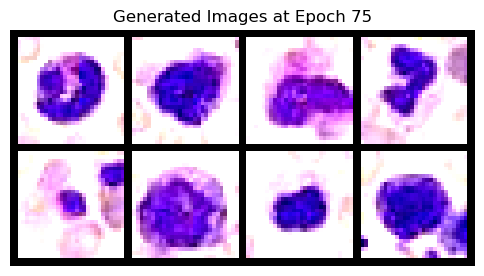

Sampling: 1000it [00:37, 26.73it/s]
Sampling: 1000it [00:36, 27.59it/s]


Epoch 75 FID: 87.4541
No improvement for 5 evaluations
Early stopping at epoch 75


Sampling: 1000it [00:37, 26.63it/s]
Sampling: 1000it [00:37, 26.71it/s]
Sampling: 1000it [00:37, 26.75it/s]
Sampling: 1000it [00:37, 26.66it/s]
Sampling: 1000it [00:37, 26.68it/s]
Sampling: 1000it [00:37, 26.64it/s]
Sampling: 1000it [00:37, 26.72it/s]
Sampling: 1000it [00:31, 31.68it/s]


FID Score: 50.8363

Hyperparameter combination 6/6
Configuration: {'batch_size': 128, 'epochs': 100, 'learning_rate': 0.0005, 'model_channels': 128, 'time_emb_dim': 256}


Epoch 1/100: 100%|██████████| 268/268 [00:56<00:00,  4.74it/s]


...

Epoch 4/100: 100%|██████████| 268/268 [00:57<00:00,  4.70it/s]


Epoch 4/100 | Loss: 0.051851


Epoch 5/100: 100%|██████████| 268/268 [00:57<00:00,  4.70it/s]


Epoch 5/100 | Loss: 0.049782


Sampling: 1000it [00:13, 73.53it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


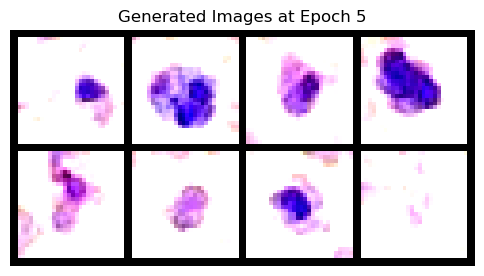

Sampling: 1000it [01:42,  9.75it/s]
Sampling: 1000it [01:41,  9.82it/s]


Epoch 5 FID: 182.1633
New best FID: 182.1633


Epoch 6/100: 100%|██████████| 268/268 [00:56<00:00,  4.75it/s]


Epoch 6/100 | Loss: 0.047381


Epoch 7/100: 100%|██████████| 268/268 [00:56<00:00,  4.72it/s]


...

Epoch 9/100: 100%|██████████| 268/268 [00:56<00:00,  4.71it/s]


Epoch 9/100 | Loss: 0.046261


Epoch 10/100: 100%|██████████| 268/268 [00:57<00:00,  4.69it/s]


Epoch 10/100 | Loss: 0.045417


Sampling: 1000it [00:13, 74.06it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


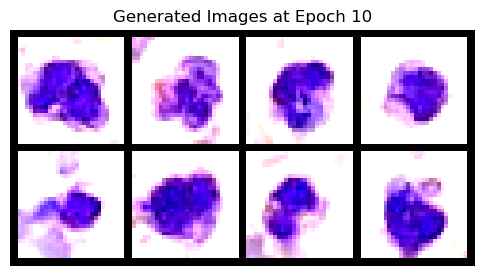

Sampling: 1000it [01:42,  9.75it/s]
Sampling: 1000it [01:41,  9.83it/s]


Epoch 10 FID: 192.5381
No improvement for 1 evaluations


Epoch 11/100: 100%|██████████| 268/268 [00:56<00:00,  4.73it/s]


Epoch 11/100 | Loss: 0.045920


Epoch 12/100: 100%|██████████| 268/268 [00:56<00:00,  4.71it/s]


...

Epoch 14/100: 100%|██████████| 268/268 [00:56<00:00,  4.71it/s]


Epoch 14/100 | Loss: 0.045192


Epoch 15/100: 100%|██████████| 268/268 [00:56<00:00,  4.73it/s]


Epoch 15/100 | Loss: 0.043928


Sampling: 1000it [00:13, 73.44it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


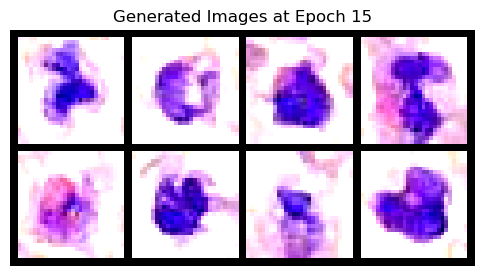

Sampling: 1000it [01:42,  9.75it/s]
Sampling: 1000it [01:41,  9.81it/s]


Epoch 15 FID: 198.1160
No improvement for 2 evaluations


Epoch 16/100: 100%|██████████| 268/268 [00:56<00:00,  4.75it/s]


Epoch 16/100 | Loss: 0.044682


Epoch 17/100: 100%|██████████| 268/268 [00:57<00:00,  4.70it/s]


...

Epoch 19/100: 100%|██████████| 268/268 [00:56<00:00,  4.70it/s]


Epoch 19/100 | Loss: 0.043210


Epoch 20/100: 100%|██████████| 268/268 [00:57<00:00,  4.70it/s]


Epoch 20/100 | Loss: 0.044404


Sampling: 1000it [00:13, 74.15it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


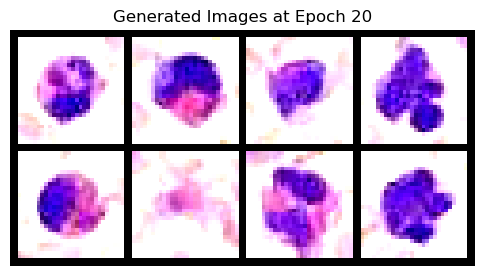

Sampling: 1000it [01:42,  9.74it/s]
Sampling: 1000it [01:41,  9.83it/s]


Epoch 20 FID: 136.8644
New best FID: 136.8644


Epoch 21/100: 100%|██████████| 268/268 [00:56<00:00,  4.75it/s]


Epoch 21/100 | Loss: 0.042989


Epoch 22/100: 100%|██████████| 268/268 [00:56<00:00,  4.74it/s]


...

Epoch 24/100: 100%|██████████| 268/268 [00:56<00:00,  4.71it/s]


Epoch 24/100 | Loss: 0.041946


Epoch 25/100: 100%|██████████| 268/268 [00:56<00:00,  4.71it/s]


Epoch 25/100 | Loss: 0.042031


Sampling: 1000it [00:13, 73.35it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


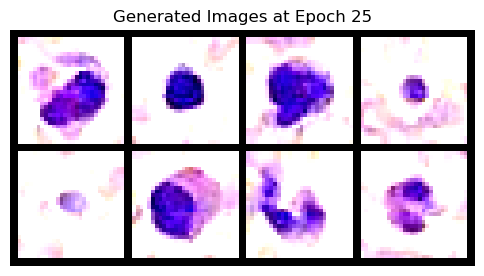

Sampling: 1000it [01:42,  9.73it/s]
Sampling: 1000it [01:41,  9.83it/s]


Epoch 25 FID: 132.4148
New best FID: 132.4148


Epoch 26/100: 100%|██████████| 268/268 [00:56<00:00,  4.76it/s]


Epoch 26/100 | Loss: 0.041476


Epoch 27/100: 100%|██████████| 268/268 [00:57<00:00,  4.70it/s]


...

Epoch 29/100: 100%|██████████| 268/268 [00:56<00:00,  4.71it/s]


Epoch 29/100 | Loss: 0.042251


Epoch 30/100: 100%|██████████| 268/268 [00:57<00:00,  4.68it/s]


Epoch 30/100 | Loss: 0.040921


Sampling: 1000it [00:13, 73.73it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


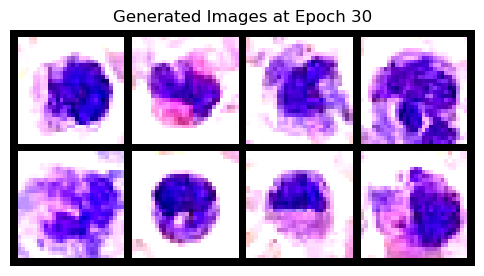

Sampling: 1000it [01:42,  9.72it/s]
Sampling: 1000it [01:42,  9.79it/s]


Epoch 30 FID: 208.9311
No improvement for 1 evaluations


Epoch 31/100: 100%|██████████| 268/268 [00:56<00:00,  4.76it/s]


Epoch 31/100 | Loss: 0.042139


Epoch 32/100: 100%|██████████| 268/268 [00:56<00:00,  4.70it/s]


...

Epoch 34/100: 100%|██████████| 268/268 [00:56<00:00,  4.71it/s]


Epoch 34/100 | Loss: 0.041742


Epoch 35/100: 100%|██████████| 268/268 [00:56<00:00,  4.71it/s]


Epoch 35/100 | Loss: 0.041960


Sampling: 1000it [00:13, 72.76it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


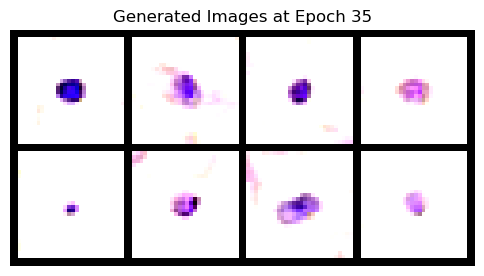

Sampling: 1000it [01:42,  9.73it/s]
Sampling: 1000it [01:41,  9.82it/s]


Epoch 35 FID: 192.8446
No improvement for 2 evaluations


Epoch 36/100: 100%|██████████| 268/268 [00:56<00:00,  4.76it/s]


Epoch 36/100 | Loss: 0.041503


Epoch 37/100: 100%|██████████| 268/268 [00:56<00:00,  4.70it/s]


...

Epoch 39/100: 100%|██████████| 268/268 [00:56<00:00,  4.71it/s]


Epoch 39/100 | Loss: 0.040511


Epoch 40/100: 100%|██████████| 268/268 [00:57<00:00,  4.70it/s]


Epoch 40/100 | Loss: 0.039680


Sampling: 1000it [00:13, 73.45it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


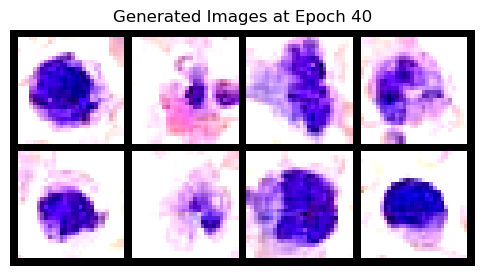

Sampling: 1000it [01:42,  9.73it/s]
Sampling: 1000it [01:41,  9.82it/s]


Epoch 40 FID: 151.1991
No improvement for 3 evaluations


Epoch 41/100: 100%|██████████| 268/268 [00:56<00:00,  4.75it/s]


Epoch 41/100 | Loss: 0.041095


Epoch 42/100: 100%|██████████| 268/268 [00:56<00:00,  4.72it/s]


...

Epoch 44/100: 100%|██████████| 268/268 [00:57<00:00,  4.69it/s]


Epoch 44/100 | Loss: 0.039981


Epoch 45/100: 100%|██████████| 268/268 [00:56<00:00,  4.70it/s]


Epoch 45/100 | Loss: 0.039804


Sampling: 1000it [00:13, 73.68it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


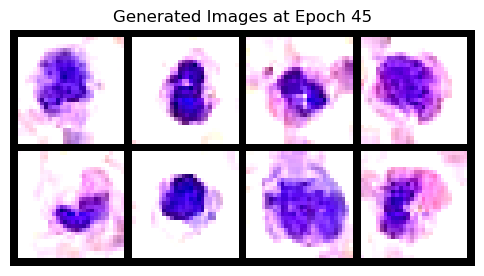

Sampling: 1000it [01:42,  9.75it/s]
Sampling: 1000it [01:41,  9.82it/s]


Epoch 45 FID: 119.3111
New best FID: 119.3111


Epoch 46/100: 100%|██████████| 268/268 [00:56<00:00,  4.77it/s]


Epoch 46/100 | Loss: 0.040756


Epoch 47/100: 100%|██████████| 268/268 [00:56<00:00,  4.71it/s]


...

Epoch 49/100: 100%|██████████| 268/268 [00:57<00:00,  4.70it/s]


Epoch 49/100 | Loss: 0.040321


Epoch 50/100: 100%|██████████| 268/268 [00:56<00:00,  4.71it/s]


Epoch 50/100 | Loss: 0.045774


Sampling: 1000it [00:13, 73.60it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


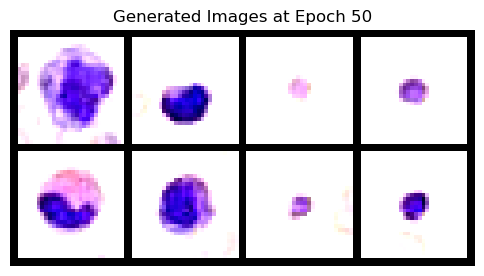

Sampling: 1000it [01:42,  9.74it/s]
Sampling: 1000it [01:41,  9.82it/s]


Epoch 50 FID: 165.8443
No improvement for 1 evaluations


Epoch 51/100: 100%|██████████| 268/268 [00:56<00:00,  4.75it/s]


Epoch 51/100 | Loss: 0.039308


Epoch 52/100: 100%|██████████| 268/268 [00:56<00:00,  4.72it/s]


...

Epoch 54/100: 100%|██████████| 268/268 [00:56<00:00,  4.70it/s]


Epoch 54/100 | Loss: 0.037947


Epoch 55/100: 100%|██████████| 268/268 [00:56<00:00,  4.71it/s]


Epoch 55/100 | Loss: 0.037713


Sampling: 1000it [00:13, 73.05it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


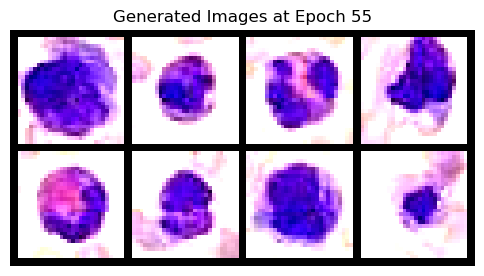

Sampling: 1000it [01:42,  9.74it/s]
Sampling: 1000it [01:41,  9.82it/s]


Epoch 55 FID: 112.4490
New best FID: 112.4490


Epoch 56/100: 100%|██████████| 268/268 [00:56<00:00,  4.76it/s]


Epoch 56/100 | Loss: 0.038322


Epoch 57/100: 100%|██████████| 268/268 [00:56<00:00,  4.72it/s]


...

Epoch 59/100: 100%|██████████| 268/268 [00:56<00:00,  4.71it/s]


Epoch 59/100 | Loss: 0.038313


Epoch 60/100: 100%|██████████| 268/268 [00:56<00:00,  4.71it/s]


Epoch 60/100 | Loss: 0.039091


Sampling: 1000it [00:13, 74.20it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


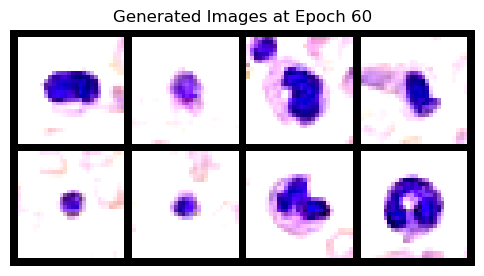

Sampling: 1000it [01:42,  9.75it/s]
Sampling: 1000it [01:41,  9.82it/s]


Epoch 60 FID: 65.9803
New best FID: 65.9803


Epoch 61/100: 100%|██████████| 268/268 [00:57<00:00,  4.66it/s]


Epoch 61/100 | Loss: 0.038743


Epoch 62/100: 100%|██████████| 268/268 [00:57<00:00,  4.70it/s]


...

Epoch 64/100: 100%|██████████| 268/268 [00:56<00:00,  4.72it/s]


Epoch 64/100 | Loss: 0.038268


Epoch 65/100: 100%|██████████| 268/268 [00:57<00:00,  4.70it/s]


Epoch 65/100 | Loss: 0.038500


Sampling: 1000it [00:13, 73.42it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


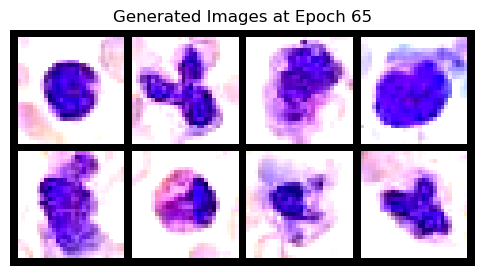

Sampling: 1000it [01:42,  9.74it/s]
Sampling: 1000it [01:41,  9.81it/s]


Epoch 65 FID: 108.8942
No improvement for 1 evaluations


Epoch 66/100: 100%|██████████| 268/268 [00:56<00:00,  4.76it/s]


Epoch 66/100 | Loss: 0.038115


Epoch 67/100: 100%|██████████| 268/268 [00:56<00:00,  4.71it/s]


...

Epoch 69/100: 100%|██████████| 268/268 [00:56<00:00,  4.72it/s]


Epoch 69/100 | Loss: 0.038015


Epoch 70/100: 100%|██████████| 268/268 [00:56<00:00,  4.71it/s]


Epoch 70/100 | Loss: 0.037217


Sampling: 1000it [00:13, 73.36it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


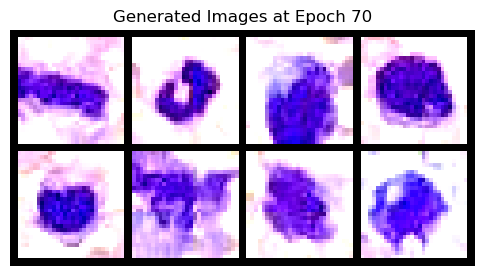

Sampling: 1000it [01:42,  9.73it/s]
Sampling: 1000it [01:41,  9.81it/s]


Epoch 70 FID: 152.2495
No improvement for 2 evaluations


Epoch 71/100: 100%|██████████| 268/268 [00:56<00:00,  4.75it/s]


Epoch 71/100 | Loss: 0.037741


Epoch 72/100: 100%|██████████| 268/268 [00:56<00:00,  4.71it/s]


...

Epoch 74/100: 100%|██████████| 268/268 [00:56<00:00,  4.72it/s]


Epoch 74/100 | Loss: 0.038038


Epoch 75/100: 100%|██████████| 268/268 [00:56<00:00,  4.70it/s]


Epoch 75/100 | Loss: 0.037834


Sampling: 1000it [00:13, 73.36it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


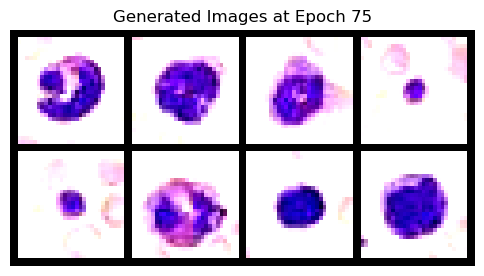

Sampling: 1000it [01:42,  9.74it/s]
Sampling: 1000it [01:41,  9.82it/s]


Epoch 75 FID: 63.3828
New best FID: 63.3828


Epoch 76/100: 100%|██████████| 268/268 [00:56<00:00,  4.73it/s]


Epoch 76/100 | Loss: 0.037784


Epoch 77/100: 100%|██████████| 268/268 [00:56<00:00,  4.73it/s]


...

Epoch 79/100: 100%|██████████| 268/268 [00:56<00:00,  4.72it/s]


Epoch 79/100 | Loss: 0.037737


Epoch 80/100: 100%|██████████| 268/268 [00:57<00:00,  4.70it/s]


Epoch 80/100 | Loss: 0.037915


Sampling: 1000it [00:13, 73.52it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


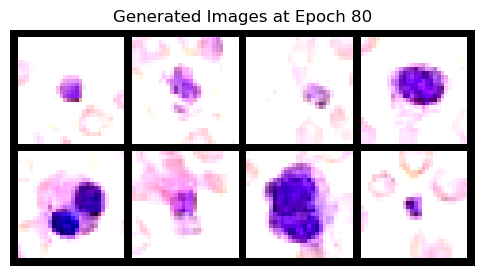

Sampling: 1000it [01:42,  9.73it/s]
Sampling: 1000it [01:41,  9.82it/s]


Epoch 80 FID: 78.1446
No improvement for 1 evaluations


Epoch 81/100: 100%|██████████| 268/268 [00:56<00:00,  4.74it/s]


Epoch 81/100 | Loss: 0.036775


Epoch 82/100: 100%|██████████| 268/268 [00:56<00:00,  4.71it/s]


...

Epoch 84/100: 100%|██████████| 268/268 [00:56<00:00,  4.71it/s]


Epoch 84/100 | Loss: 0.036861


Epoch 85/100: 100%|██████████| 268/268 [00:56<00:00,  4.70it/s]


Epoch 85/100 | Loss: 0.036716


Sampling: 1000it [00:13, 73.81it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


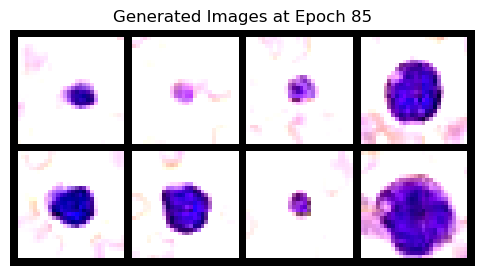

Sampling: 1000it [01:42,  9.75it/s]
Sampling: 1000it [01:41,  9.82it/s]


Epoch 85 FID: 74.3456
No improvement for 2 evaluations


Epoch 86/100: 100%|██████████| 268/268 [00:56<00:00,  4.75it/s]


Epoch 86/100 | Loss: 0.037134


Epoch 87/100: 100%|██████████| 268/268 [00:56<00:00,  4.71it/s]


...

Epoch 89/100: 100%|██████████| 268/268 [00:56<00:00,  4.71it/s]


Epoch 89/100 | Loss: 0.036841


Epoch 90/100: 100%|██████████| 268/268 [00:56<00:00,  4.71it/s]


Epoch 90/100 | Loss: 0.036588


Sampling: 1000it [00:13, 74.11it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


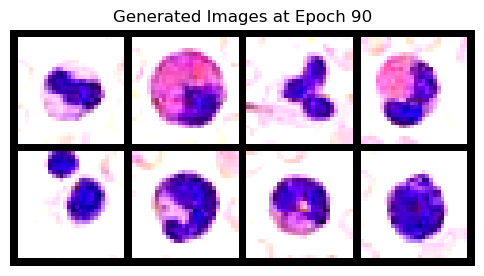

Sampling: 1000it [01:42,  9.74it/s]
Sampling: 1000it [01:41,  9.83it/s]


Epoch 90 FID: 60.2802
New best FID: 60.2802


Epoch 91/100: 100%|██████████| 268/268 [00:56<00:00,  4.77it/s]


Epoch 91/100 | Loss: 0.036926


Epoch 92/100: 100%|██████████| 268/268 [00:56<00:00,  4.73it/s]


...

Epoch 94/100: 100%|██████████| 268/268 [00:56<00:00,  4.73it/s]


Epoch 94/100 | Loss: 0.035695


Epoch 95/100: 100%|██████████| 268/268 [00:56<00:00,  4.71it/s]


Epoch 95/100 | Loss: 0.036574


Sampling: 1000it [00:13, 73.84it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


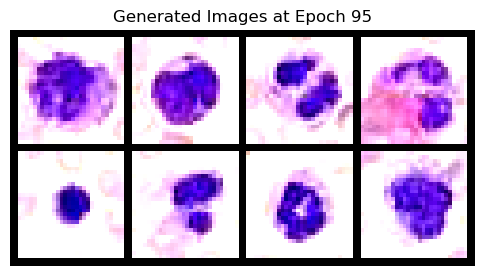

Sampling: 1000it [01:42,  9.72it/s]
Sampling: 1000it [01:41,  9.81it/s]


Epoch 95 FID: 57.8099
New best FID: 57.8099


Epoch 96/100: 100%|██████████| 268/268 [00:56<00:00,  4.75it/s]


Epoch 96/100 | Loss: 0.036768


Epoch 97/100: 100%|██████████| 268/268 [00:56<00:00,  4.70it/s]


...

Epoch 99/100: 100%|██████████| 268/268 [00:56<00:00,  4.71it/s]


Epoch 99/100 | Loss: 0.036845


Epoch 100/100: 100%|██████████| 268/268 [00:57<00:00,  4.70it/s]


Epoch 100/100 | Loss: 0.036723


Sampling: 1000it [00:13, 73.58it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


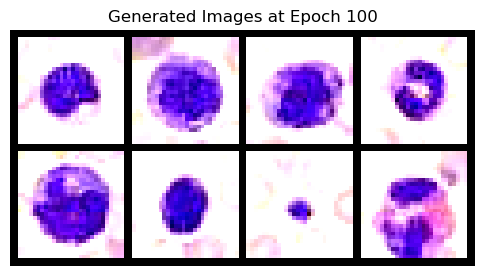

Sampling: 1000it [01:42,  9.74it/s]
Sampling: 1000it [01:41,  9.83it/s]


Epoch 100 FID: 81.6998
No improvement for 1 evaluations


Sampling: 1000it [01:42,  9.72it/s]
Sampling: 1000it [01:42,  9.72it/s]
Sampling: 1000it [01:42,  9.72it/s]
Sampling: 1000it [01:42,  9.72it/s]
Sampling: 1000it [01:43,  9.70it/s]
Sampling: 1000it [01:42,  9.73it/s]
Sampling: 1000it [01:43,  9.71it/s]
Sampling: 1000it [01:26, 11.60it/s]


FID Score: 47.9006

=== Best Hyperparameter Configuration ===
FID Score: 38.4036
Configuration: {'batch_size': 128, 'epochs': 100, 'learning_rate': 0.0002, 'model_channels': 128, 'time_emb_dim': 256}


In [ ]:
# Define hyperparameter grid for DDPM
param_grid = {
    'model_channels': [64, 128],           # 2 values
    'time_emb_dim': [256],                 # 1 value (fixed to larger value)
    'learning_rate': [1e-4, 2e-4, 5e-4],   # 3 values
    'batch_size': [128],                   # 1 value (fixed to larger value)
    'epochs': [100]                         # 1 value
}

# Convert grid to list of combinations
hyperparameter_combinations = list(ParameterGrid(param_grid))
print(f"Total combinations: {len(hyperparameter_combinations)}")

# Results storage
results = [
    # Include the result already obtained from the first combination
    {
        'hyperparams': {
            'model_channels': 64, 
            'time_emb_dim': 256, 
            'learning_rate': 1e-4, 
            'batch_size': 128, 
            'epochs': 100
        },
        'fid': 60.085,
        'losses': []  # Since we don't have the loss history, we leave it empty
    }
]

# Set the starting index to skip already tested combinations
start_idx = 1  # Start from the second combination

# Set best configuration for memory conservation
torch.cuda.empty_cache()  # Clear CUDA cache before starting
torch.backends.cudnn.benchmark = False  # Disable CUDA benchmarking
torch.backends.cudnn.deterministic = True  # Ensure determinism

# Run hyperparameter search from the untested combination
for i, hyperparams in enumerate(hyperparameter_combinations[start_idx:], start=start_idx+1):
    print(f"\nHyperparameter combination {i}/{len(hyperparameter_combinations)}")
    print(f"Configuration: {hyperparams}")
    
    # Clear CUDA memory before each combination
    torch.cuda.empty_cache()
    
    # Set seed for reproducibility
    set_seed(INITIAL_SEED)
    
    try:
        # Use a smaller batch size for memory savings, regardless of the grid value
        # According to your hyperparameters, we want to use batch_size=128, but
        # we can train with 64 and evaluate with 128 to save memory
        effective_batch_size = 64  # Reduce to save memory
        accum_steps = hyperparams['batch_size'] // effective_batch_size  # Gradient accumulation
        
        train_loader = DataLoader(
            full_dataset,
            batch_size=effective_batch_size,
            shuffle=True,
            num_workers=2,  # Reduce number of workers to save memory
            pin_memory=True if torch.cuda.is_available() else False
        )
        
        # Initialize model
        model = SimpleUnet(
            in_channels=n_channels,
            model_channels=hyperparams['model_channels'],
            time_emb_dim=hyperparams['time_emb_dim']
        ).to(DEVICE)
        
        # Initialize optimizer
        optimizer = optim.Adam(model.parameters(), lr=hyperparams['learning_rate'])
        
        # Train model with gradient accumulation
        def train_ddpm_memory_efficient(model, dataloader, optimizer, hyperparams, device, 
                                       eval_interval=5, patience=5, accum_steps=1):
            """Modified version of train_ddpm with gradient accumulation and memory management"""
            epochs = hyperparams['epochs']
            
            # Sample a small subset of data for quick FID evaluation
            eval_size = 250  # Use a smaller sample to save memory
            eval_indices = torch.randperm(len(dataloader.dataset))[:eval_size]
            eval_data = torch.stack([dataloader.dataset[i][0] for i in eval_indices]).to('cpu')  # Keep on CPU
            
            # For early stopping
            best_fid = float('inf')
            best_model_state = None
            no_improvement = 0
            
            # For progress tracking
            losses = []
            
            for epoch in range(epochs):
                epoch_losses = []
                model.train()
                optimizer.zero_grad()
                
                # Process batches with gradient accumulation
                for batch_idx, (images, _) in enumerate(tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}")):
                    images = images.to(device)
                    batch_size = images.shape[0]
                    
                    # Sample random timesteps
                    t = sample_timesteps(batch_size, T, device)
                    
                    # Add noise to the images
                    x_t, noise = forward_diffusion_sample(images, t, device)
                    
                    # Predict the noise
                    predicted_noise = model(x_t, t)
                    
                    # Calculate loss
                    loss = F.mse_loss(predicted_noise, noise)
                    
                    # Divide the loss by the number of accumulation steps
                    loss = loss / accum_steps
                    
                    # Backpropagation
                    loss.backward()
                    
                    # Only update weights after accumulating gradients
                    if (batch_idx + 1) % accum_steps == 0 or batch_idx + 1 == len(dataloader):
                        optimizer.step()
                        optimizer.zero_grad()
                    
                    epoch_losses.append(loss.item() * accum_steps)  # Multiply back to record actual loss
                    
                    # Free memory
                    del images, x_t, noise, predicted_noise
                    torch.cuda.empty_cache()
                
                # Average losses for this epoch
                avg_loss = sum(epoch_losses) / len(epoch_losses)
                losses.append(avg_loss)
                
                # Report progress
                print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.6f}")
                
                # Free CUDA memory
                torch.cuda.empty_cache()
                
                # Early stopping and periodic evaluation
                if (epoch+1) % eval_interval == 0:
                    model.eval()
                    
                    # Generate some synthetic images for visualization
                    with torch.no_grad():
                        samples = sample_ddpm(model, 8, T, 28, device, channels=n_channels)
                        # Normalize for visualization
                        samples_normalized = (samples + 1) / 2
                        grid = make_grid(samples_normalized, nrow=4)
                        plt.figure(figsize=(6, 6))
                        plt.axis("off")
                        plt.title(f"Generated Images at Epoch {epoch+1}")
                        plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
                        plt.show()
                        plt.close()  # Close the figure to save memory
                    
                    # Evaluate FID for early stopping
                    eval_data = eval_data.to(device)  # Temporarily move data to GPU
                    current_fid, _ = evaluate_model_fid(
                        model, eval_data, n_samples=len(eval_data), img_size=28, channels=n_channels
                    )
                    eval_data = eval_data.to('cpu')  # Move data back to CPU
                    
                    print(f"Epoch {epoch+1} FID: {current_fid:.4f}")
                    
                    if current_fid < best_fid:
                        best_fid = current_fid
                        # Save only parameters instead of entire state dict to save memory
                        best_model_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
                        no_improvement = 0
                        print(f"New best FID: {best_fid:.4f}")
                    else:
                        no_improvement += 1
                        print(f"No improvement for {no_improvement} evaluations")
                        
                    if no_improvement >= patience:
                        print(f"Early stopping at epoch {epoch+1}")
                        break
                
                # Free memory between epochs
                torch.cuda.empty_cache()
            
            # Load best model
            if best_model_state is not None:
                model.load_state_dict({k: v.to(device) for k, v in best_model_state.items()})
            
            return model, losses, best_fid
        
        # Train with efficient memory management
        trained_model, losses, best_fid = train_ddpm_memory_efficient(
            model,
            train_loader, 
            optimizer,
            hyperparams,
            DEVICE,
            eval_interval=5,    # Evaluate every 5 epochs
            patience=5,         # Stop after 5 evaluations without improvement
            accum_steps=accum_steps  # Use gradient accumulation
        )
        
        # Free memory
        torch.cuda.empty_cache()
        
        # Evaluate the model with a smaller set of data
        eval_samples = 1000  # Reduce to save memory
        fid_score, fake_samples = evaluate_model_fid(
            trained_model, 
            real_samples[:eval_samples],
            n_samples=eval_samples,  # Use fewer samples for final evaluation
            img_size=28, 
            channels=n_channels
        )
        
        # Free large objects
        del fake_samples
        torch.cuda.empty_cache()
        
        # Save results - store only what's necessary
        results.append({
            'hyperparams': hyperparams,
            'fid': fid_score,
            'model_state': trained_model.state_dict(),
            'losses': losses
        })
        
        # Save checkpoint for safety
        torch.save({
            'results': results,
            'last_idx': i
        }, f'ddpm_checkpoint_{i}.pth')
        
        print(f"FID Score: {fid_score:.4f}")
        
    except RuntimeError as e:
        if 'CUDA out of memory' in str(e):
            print(f"CUDA out of memory error on combination {i}. Skipping this combination.")
            print(f"Error details: {str(e)}")
            # Log failure for this combination
            results.append({
                'hyperparams': hyperparams,
                'fid': float('inf'),  # Use infinity to indicate failure
                'error': 'CUDA OOM'
            })
            # Clear memory and continue with the next combination
            torch.cuda.empty_cache()
            continue
        else:
            raise e
    
    # Clean up model to free memory before the next combination
    del model, optimizer, trained_model
    torch.cuda.empty_cache()

# Sort results by FID score (lower is better)
valid_results = [r for r in results if 'error' not in r]
if valid_results:
    valid_results.sort(key=lambda x: x['fid'])
    
    # Print the best configuration
    best_result = valid_results[0]
    print("\n=== Best Hyperparameter Configuration ===")
    print(f"FID Score: {best_result['fid']:.4f}")
    print(f"Configuration: {best_result['hyperparams']}")
    
    # Save the best model
    if 'model_state' in best_result:
        torch.save(best_result['model_state'], 'best_bloodmnist_ddpm.pth')
else:
    print("No valid combinations were successfully completed.")

## Evaluation for 5 different seeds


=== Avaliando o Melhor Modelo com Múltiplas Seeds ===

Avaliação 1/5 com seed 42


Sampling: 1000it [01:41,  9.84it/s]
Sampling: 1000it [01:42,  9.76it/s]
Sampling: 1000it [01:42,  9.73it/s]
Sampling: 1000it [01:42,  9.72it/s]
Sampling: 1000it [01:43,  9.71it/s]
Sampling: 1000it [01:42,  9.73it/s]
Sampling: 1000it [01:43,  9.70it/s]
Sampling: 1000it [01:43,  9.69it/s]
Sampling: 1000it [01:43,  9.70it/s]
Sampling: 1000it [01:43,  9.69it/s]
Sampling: 1000it [01:43,  9.68it/s]
Sampling: 1000it [01:43,  9.68it/s]
Sampling: 1000it [01:43,  9.68it/s]
Sampling: 1000it [01:43,  9.66it/s]
Sampling: 1000it [01:43,  9.69it/s]
Sampling: 1000it [01:08, 14.59it/s]


FID Score para avaliação 1 (seed 42): 36.6847


Sampling: 1000it [00:20, 49.41it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


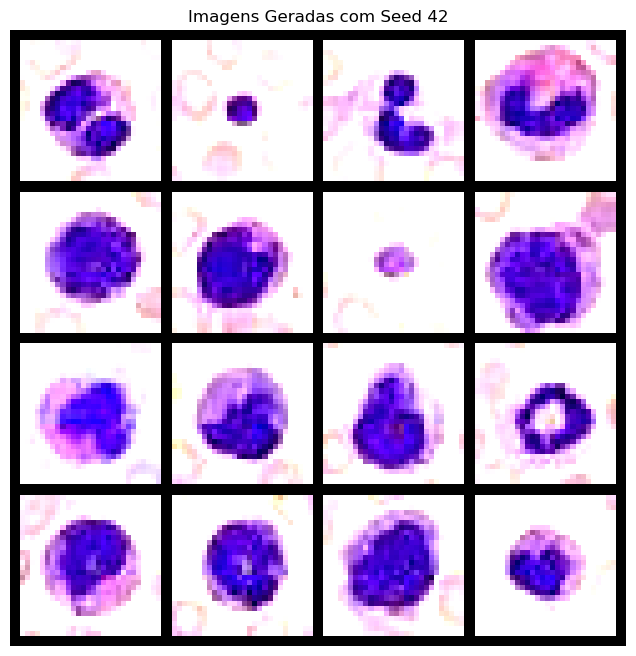


Avaliação 2/5 com seed 123


Sampling: 1000it [01:43,  9.69it/s]
Sampling: 1000it [01:43,  9.69it/s]
Sampling: 1000it [01:43,  9.69it/s]
Sampling: 1000it [01:43,  9.68it/s]
Sampling: 1000it [01:43,  9.69it/s]
Sampling: 1000it [01:43,  9.67it/s]
Sampling: 1000it [01:43,  9.70it/s]
Sampling: 1000it [01:43,  9.70it/s]
Sampling: 1000it [01:43,  9.68it/s]
Sampling: 1000it [01:43,  9.69it/s]
Sampling: 1000it [01:43,  9.68it/s]
Sampling: 1000it [01:43,  9.68it/s]
Sampling: 1000it [01:43,  9.69it/s]
Sampling: 1000it [01:43,  9.68it/s]
Sampling: 1000it [01:43,  9.68it/s]
Sampling: 1000it [01:08, 14.56it/s]


FID Score para avaliação 2 (seed 123): 37.1043


Sampling: 1000it [00:20, 48.78it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


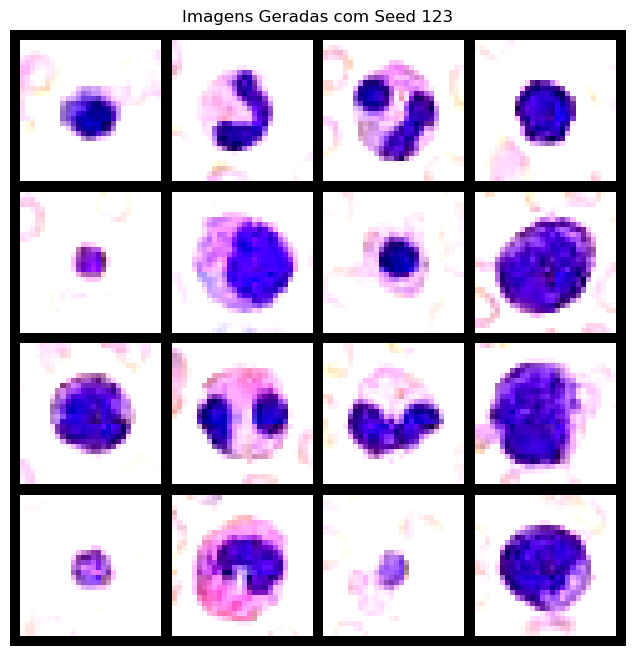


Avaliação 3/5 com seed 456


Sampling: 1000it [01:43,  9.69it/s]
Sampling: 1000it [01:43,  9.69it/s]
Sampling: 1000it [01:43,  9.69it/s]
Sampling: 1000it [01:43,  9.69it/s]
Sampling: 1000it [01:43,  9.68it/s]
Sampling: 1000it [01:43,  9.69it/s]
Sampling: 1000it [01:43,  9.68it/s]
Sampling: 1000it [01:43,  9.68it/s]
Sampling: 1000it [01:43,  9.66it/s]
Sampling: 1000it [01:43,  9.65it/s]
Sampling: 1000it [01:43,  9.68it/s]
Sampling: 1000it [01:43,  9.68it/s]
Sampling: 1000it [01:43,  9.68it/s]
Sampling: 1000it [01:43,  9.68it/s]
Sampling: 1000it [01:43,  9.67it/s]
Sampling: 1000it [01:08, 14.62it/s]


FID Score para avaliação 3 (seed 456): 39.8244


Sampling: 1000it [00:20, 49.67it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


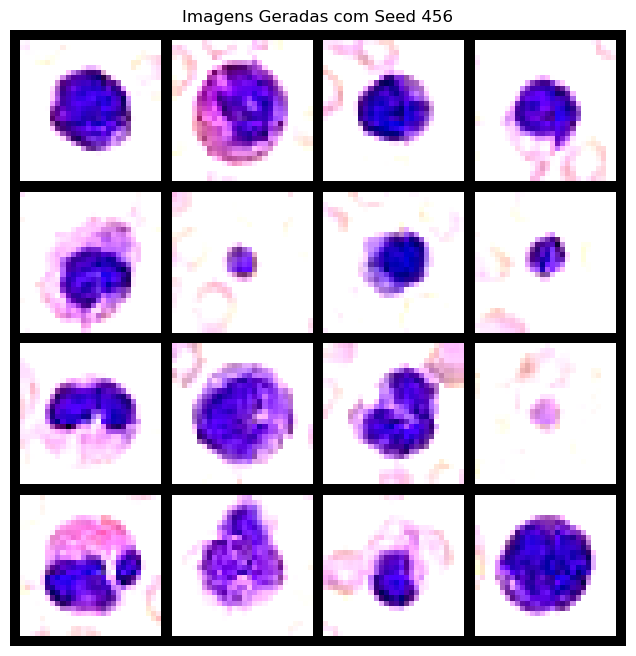


Avaliação 4/5 com seed 789


Sampling: 1000it [01:43,  9.69it/s]
Sampling: 1000it [01:43,  9.66it/s]
Sampling: 1000it [01:43,  9.67it/s]
Sampling: 1000it [01:43,  9.66it/s]
Sampling: 1000it [01:43,  9.68it/s]
Sampling: 1000it [01:43,  9.66it/s]
Sampling: 1000it [01:43,  9.66it/s]
Sampling: 1000it [01:43,  9.66it/s]
Sampling: 1000it [01:43,  9.67it/s]
Sampling: 1000it [01:43,  9.66it/s]
Sampling: 1000it [01:43,  9.66it/s]
Sampling: 1000it [01:43,  9.66it/s]
Sampling: 1000it [01:43,  9.67it/s]
Sampling: 1000it [01:43,  9.68it/s]
Sampling: 1000it [01:43,  9.66it/s]
Sampling: 1000it [01:08, 14.55it/s]


FID Score para avaliação 4 (seed 789): 39.2925


Sampling: 1000it [00:20, 49.54it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


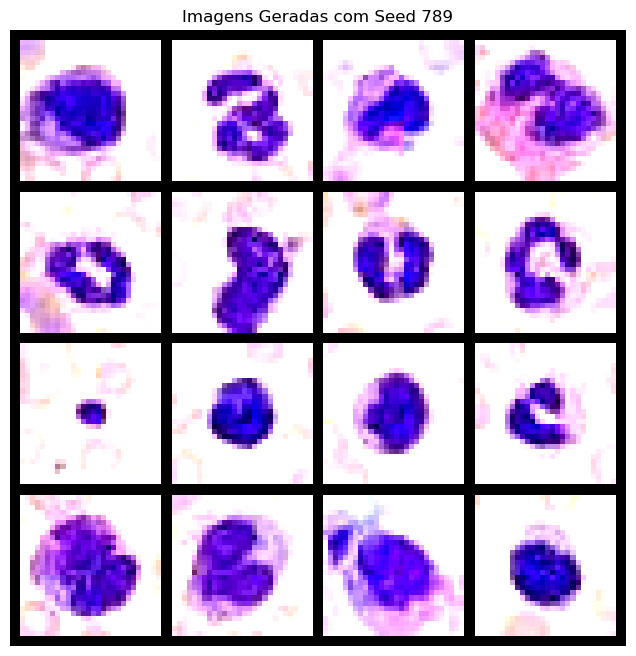


Avaliação 5/5 com seed 1010


Sampling: 1000it [01:43,  9.69it/s]
Sampling: 1000it [01:43,  9.68it/s]
Sampling: 1000it [01:43,  9.68it/s]
Sampling: 1000it [01:43,  9.69it/s]
Sampling: 1000it [01:43,  9.69it/s]
Sampling: 1000it [01:43,  9.68it/s]
Sampling: 1000it [01:43,  9.68it/s]
Sampling: 1000it [01:43,  9.68it/s]
Sampling: 1000it [01:43,  9.68it/s]
Sampling: 1000it [01:43,  9.67it/s]
Sampling: 1000it [01:43,  9.68it/s]
Sampling: 1000it [01:43,  9.68it/s]
Sampling: 1000it [01:43,  9.68it/s]
Sampling: 1000it [01:43,  9.68it/s]
Sampling: 1000it [01:43,  9.68it/s]
Sampling: 1000it [01:08, 14.59it/s]


FID Score para avaliação 5 (seed 1010): 40.1109


Sampling: 1000it [00:20, 49.19it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


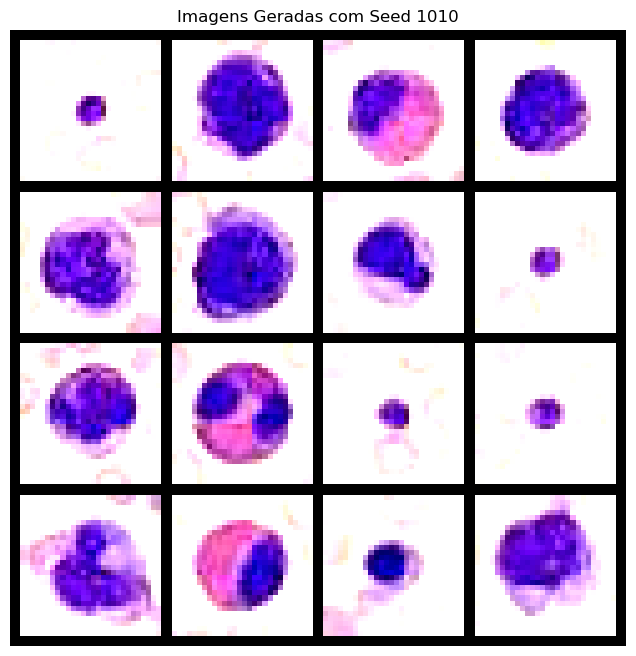


=== Resultados da Avaliação de Robustez ===
FID Score médio em 5 avaliações: 38.6033 ± 1.4260
Avaliação 1 (Seed 42): FID = 36.6847
Avaliação 2 (Seed 123): FID = 37.1043
Avaliação 3 (Seed 456): FID = 39.8244
Avaliação 4 (Seed 789): FID = 39.2925
Avaliação 5 (Seed 1010): FID = 40.1109


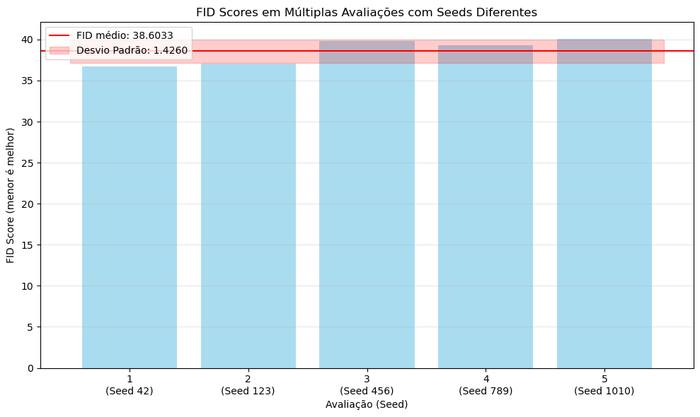

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


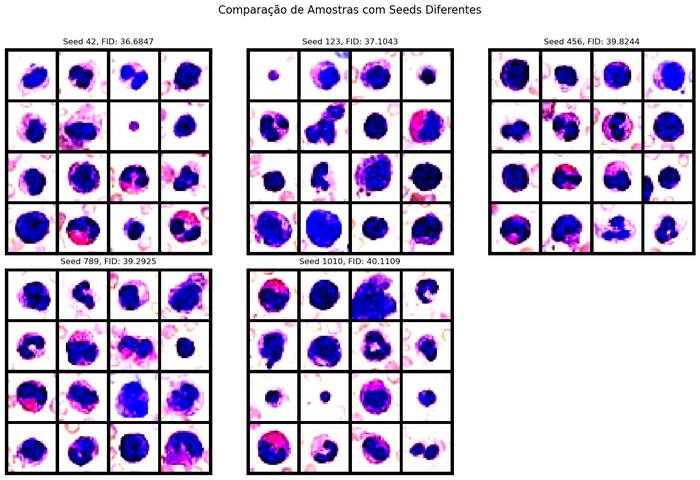


=== Conclusão sobre Robustez ===
O modelo DDPM com os melhores hiperparâmetros foi avaliado usando 5 seeds diferentes.
FID Score Médio: 38.6033 ± 1.4260
Coeficiente de Variação: 3.69%


In [ ]:
# Use the best hyperparameters found
best_hyperparams = best_result['hyperparams']
best_model_state = best_result['model_state']

# Load the model with the best parameters
best_model = SimpleUnet(
    in_channels=n_channels,
    model_channels=best_hyperparams['model_channels'],
    time_emb_dim=best_hyperparams['time_emb_dim']
).to(DEVICE)
best_model.load_state_dict(best_model_state)

# Prepare for multiple evaluations with different seeds
num_runs = 5
seeds = [42, 123, 456, 789, 1010]  # Different seeds for each evaluation
fid_scores = []
all_fake_samples = []

print("\n=== Evaluating Best Model with Multiple Seeds ===")

for run_idx, seed in enumerate(seeds):
    print(f"\nEvaluation {run_idx+1}/{num_runs} with seed {seed}")
    
    # Set seed for reproducibility in generation
    set_seed(seed)
    
    # Evaluate the model with the current seed
    fid_score, fake_samples = evaluate_model_fid(
        best_model, 
        real_samples,
        n_samples=2000,  # Use 2000 samples for evaluation
        img_size=28, 
        channels=n_channels
    )
    
    # Store results
    fid_scores.append(fid_score)
    all_fake_samples.append(fake_samples[:100])  # Store 100 samples for visualization
    
    print(f"FID Score for evaluation {run_idx+1} (seed {seed}): {fid_score:.4f}")
    
    # Visualize some generated samples
    with torch.no_grad():
        # Use the same model but with different seed for generation
        samples = sample_ddpm(best_model, 16, T, 28, DEVICE, channels=n_channels)
        samples_normalized = (samples + 1) / 2
        grid = make_grid(samples_normalized, nrow=4)
        plt.figure(figsize=(8, 8))
        plt.axis("off")
        plt.title(f"Generated Images with Seed {seed}")
        plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
        plt.show()

# Calculate mean and standard deviation of FID scores
mean_fid = np.mean(fid_scores)
std_fid = np.std(fid_scores)

print("\n=== Robustness Evaluation Results ===")
print(f"Average FID Score across {num_runs} evaluations: {mean_fid:.4f} ± {std_fid:.4f}")
for i, fid in enumerate(fid_scores):
    print(f"Evaluation {i+1} (Seed {seeds[i]}): FID = {fid:.4f}")

# Visualize FID scores from the various evaluations
plt.figure(figsize=(10, 6))
plt.bar(range(1, num_runs+1), fid_scores, color='skyblue', alpha=0.7)
plt.axhline(y=mean_fid, color='r', linestyle='-', label=f'Mean FID: {mean_fid:.4f}')
plt.fill_between(
    [0.5, num_runs+0.5], 
    [mean_fid-std_fid, mean_fid-std_fid], 
    [mean_fid+std_fid, mean_fid+std_fid], 
    color='r', alpha=0.2,
    label=f'Standard Deviation: {std_fid:.4f}'
)
plt.xlabel('Evaluation (Seed)')
plt.ylabel('FID Score (lower is better)')
plt.title('FID Scores Across Multiple Evaluations with Different Seeds')
plt.xticks(range(1, num_runs+1), [f'{i}\n(Seed {seed})' for i, seed in enumerate(seeds, 1)])
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Visualize a grid of generated images from each evaluation
plt.figure(figsize=(15, 10))
plt.suptitle("Comparison of Samples with Different Seeds", fontsize=16)

for i, samples in enumerate(all_fake_samples):
    plt.subplot(2, 3, i+1)
    grid = make_grid(samples[:16], nrow=4)
    plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
    plt.title(f"Seed {seeds[i]}, FID: {fid_scores[i]:.4f}")
    plt.axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust for the top title
plt.show()


# Conclusion on model robustness
print("\n=== Conclusion on Robustness ===")
print(f"The DDPM model with the best hyperparameters was evaluated using 5 different seeds.")
print(f"Average FID Score: {mean_fid:.4f} ± {std_fid:.4f}")
print(f"Coefficient of Variation: {(std_fid/mean_fid)*100:.2f}%")

In [45]:
print(best_result['hyperparams'])

{'batch_size': 128, 'epochs': 100, 'learning_rate': 0.0002, 'model_channels': 128, 'time_emb_dim': 256}
